# GPT-2 Source Domain Diagnosis Dataset v9

## Objective

1. **Confirm residualization procedure**: fit on train only, apply to test (no leakage)
2. **LOSO on residualized features**
3. **Counterfactual consistency metric**
4. **Consolidated final table**:
   - 4.1 Source classifier: original vs residualized
   - 4.2 Bias classifier: original vs residualized
   - 4.3 LOSO by source (original + residualized)
   - 4.4 Baseline source-only (predict bias from source majority class) on v9

## 1. Setup and Imports

In [16]:
import subprocess
import sys

try:
    import xgboost  # noqa: F401
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'xgboost'])

In [17]:
import json
import warnings
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.experimental import enable_halving_search_cv  # noqa: F401
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    GroupShuffleSplit,
    HalvingRandomSearchCV,
    StratifiedGroupKFold,
    cross_validate,
)
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from xgboost import XGBClassifier


def find_root(start: Path, repo_name: str = 'attention-atlas') -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if candidate.name == repo_name:
            return candidate
    return start


_nb_file = Path(globals().get('__vsc_ipynb_file__', '') or '')
if _nb_file.exists():
    root_dir = find_root(_nb_file.parent)
else:
    root_dir = find_root(Path.cwd())
notebook_dir = root_dir / 'dataset' / 'v2'

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(f'Root dir: {root_dir}')
print(f'Notebook dir: {notebook_dir}')

Root dir: C:\Users\anoca\Documents\GitHub\attention-atlas
Notebook dir: C:\Users\anoca\Documents\GitHub\attention-atlas\dataset\v2


## 2. Load Dataset v9

In [18]:
dataset_path = notebook_dir / 'bias_sentences_v9.json'
with open(dataset_path, encoding='utf-8') as f:
    raw = json.load(f)

df_sentences = pd.DataFrame(raw['entries'])
df_sentences['label'] = df_sentences['has_bias'].astype(int)

SOURCE_CANONICAL = {
    'biased_corpus_only': 'biased-corpus',
    'biased_corpus_v2': 'biased-corpus',
    'gemini_only': 'gemini',
    'gemini_only_v2': 'gemini',
    'gus_only': 'gus-dataset',
    'gus_only_v2': 'gus-dataset',
}
df_sentences['source_canonical'] = (
    df_sentences['source'].map(SOURCE_CANONICAL).fillna(df_sentences['source'])
)

print(f'Dataset v9: {len(df_sentences)} entries')
print(f'Unique texts: {df_sentences["text"].nunique()} / {len(df_sentences)}')
print(f'Label distribution: {df_sentences["label"].value_counts().sort_index().to_dict()}')
print(f'Sources (canonical): {df_sentences["source_canonical"].value_counts().to_dict()}')
print(f'Roles: {df_sentences["role"].value_counts().to_dict()}')

Dataset v9: 10304 entries
Unique texts: 10304 / 10304
Label distribution: {0: 4807, 1: 5497}
Sources (canonical): {'gemini': 4440, 'biased-corpus': 3235, 'gus-dataset': 2629}
Roles: {'counterfactual': 3847, 'original': 3844, 'unpaired': 2613}


In [19]:
# Cross-source text overlap
source_groups = df_sentences.groupby('source')['text'].apply(set)
source_names = list(source_groups.index)

print('Cross-source text overlap (should be 0):')
for i in range(len(source_names)):
    for j in range(i + 1, len(source_names)):
        overlap = source_groups[source_names[i]] & source_groups[source_names[j]]
        print(f'  {source_names[i]} vs {source_names[j]}: {len(overlap)}')

print('\nBias by source:')
print(pd.crosstab(df_sentences['source_canonical'], df_sentences['label'], margins=True))

print('\nRole distribution:')
print(pd.crosstab(df_sentences['source_canonical'], df_sentences['role'], margins=True))

Cross-source text overlap (should be 0):
  biased_corpus_only vs gemini_only: 0
  biased_corpus_only vs gus_only: 0
  gemini_only vs gus_only: 0

Bias by source:
label                0     1    All
source_canonical                   
biased-corpus     1169  2066   3235
gemini            2277  2163   4440
gus-dataset       1361  1268   2629
All               4807  5497  10304

Role distribution:
role              counterfactual  original  unpaired    All
source_canonical                                           
biased-corpus                956       957      1322   3235
gemini                      2158      2156       126   4440
gus-dataset                  733       731      1165   2629
All                         3847      3844      2613  10304


## 3. Load Feature Matrix

In [20]:
features_path = (
    root_dir / 'attention_app' / 'bias' / 'extracted_features'
    / 'feature_matrix_gpt2_v9.pkl'
)
if not features_path.exists():
    raise FileNotFoundError(
        f'Feature matrix not found: {features_path}\n'
        'Run the extraction script first.'
    )

df_features = pd.read_pickle(features_path).copy()
print(f'Feature matrix shape: {df_features.shape[0]} samples x {df_features.shape[1]} columns')

if len(df_features) != len(df_sentences):
    raise RuntimeError(
        f'Size mismatch: feature matrix has {len(df_features)} rows but '
        f'JSON dataset has {len(df_sentences)} rows.'
    )

label_match = np.array_equal(
    df_features['label'].astype(int).values, df_sentences['label'].values
)
print(f'Label alignment with JSON dataset: {label_match}')
if not label_match:
    raise RuntimeError('Feature matrix labels do not align with JSON dataset labels.')

for col in [
    'text', 'source', 'source_canonical', 'original_id',
    'role', 'topic', 'pair_id', 'sentence_id', 'edit_type',
]:
    if col in df_sentences.columns:
        df_features[col] = df_sentences[col].values

print(f'Source distribution: {df_features["source_canonical"].value_counts().to_dict()}')

Feature matrix shape: 10304 samples x 3239 columns
Label alignment with JSON dataset: True
Source distribution: {'gemini': 4440, 'biased-corpus': 3235, 'gus-dataset': 2629}


## 4. Prepare Data

In [21]:
drop_cols = [
    'label', 'id', 'text', 'source', 'source_canonical', 'original_id', 'role',
    'topic', 'pair_id', 'sentence_id', 'type', 'validated_source', 'hasbias',
    'has_bias', 'bias_type', 'bias_description', 'edit_spans', 'edit_type',
]

X = df_features.drop(columns=[c for c in drop_cols if c in df_features.columns])
y = df_features['label'].astype(int)
sources = df_features['source_canonical'].values

group_col = df_features['pair_id'].copy()
mask_no_pair = group_col.isna()
group_col[mask_no_pair] = [
    'unpaired_' + str(i) for i in range(mask_no_pair.sum())
]
groups = group_col.values

print(f'Total features: {X.shape[1]}')
print(f'Total samples:  {X.shape[0]}')
print(f'Unique groups:  {len(set(groups))}')
print(f'Label distribution: biased={int(y.sum())}, neutral={int((y == 0).sum())}')

print('\nSource distribution:')
for src, cnt in Counter(sources).most_common():
    src_labels = y[sources == src]
    print(
        f'  {src:18} {cnt:5d} '
        f'(biased={int(src_labels.sum())}, neutral={int((src_labels == 0).sum())})'
    )

print(f'\nRole distribution: {df_features["role"].value_counts().to_dict()}')

X_final = X.copy()
unique_sources = np.array(sorted(np.unique(sources)))

Total features: 3238
Total samples:  10304
Unique groups:  6460
Label distribution: biased=5497, neutral=4807

Source distribution:
  gemini              4440 (biased=2163, neutral=2277)
  biased-corpus       3235 (biased=2066, neutral=1169)
  gus-dataset         2629 (biased=1268, neutral=1361)

Role distribution: {'counterfactual': 3847, 'original': 3844, 'unpaired': 2613}


## 4.4. Baseline: Source-Only Prediction on v9

Compute how well one can predict `has_bias` using only the majority class per source.
This is the theoretical ceiling for a source-confounding artefact.

In [22]:
print(' Source-Only Baseline (v9) ')
print('Predict bias label using the majority class of each source.\n')

source_majority = {}
for src in unique_sources:
    src_mask = sources == src
    src_labels = y[src_mask]
    majority = int(src_labels.mode().iloc[0])
    source_majority[src] = majority
    n_correct = int((src_labels == majority).sum())
    n_total = int(src_mask.sum())
    print(
        f'  {src:18} majority={majority}  '
        f'correct={n_correct}/{n_total} ({n_correct/n_total:.1%})'
    )

# Overall source-only accuracy
y_source_baseline = pd.Series(sources).map(source_majority).astype(int).values
source_only_acc = accuracy_score(y, y_source_baseline)
source_only_f1 = f1_score(y, y_source_baseline, zero_division=0)
source_only_auc = roc_auc_score(y, y_source_baseline)

print(f'\nOverall source-only baseline:')
print(f'  Accuracy: {source_only_acc:.4f}')
print(f'  F1:       {source_only_f1:.4f}')
print(f'  AUC:      {source_only_auc:.4f}')
print(f'\nInterpretation: if the model cannot beat {source_only_acc:.1%} accuracy,'
      f' it may just be learning source identity.')

 Source-Only Baseline (v9) 


Predict bias label using the majority class of each source.

  biased-corpus      majority=1  correct=2066/3235 (63.9%)
  gemini             majority=0  correct=2277/4440 (51.3%)
  gus-dataset        majority=0  correct=1361/2629 (51.8%)

Overall source-only baseline:
  Accuracy: 0.5536
  F1:       0.4732
  AUC:      0.5663

Interpretation: if the model cannot beat 55.4% accuracy, it may just be learning source identity.


## 5. LOSO on Original Features

In [23]:
print(f'Sources for LOSO: {list(unique_sources)}\n')

loso_results = []

for test_source in unique_sources:
    print('=' * 72)
    print(f'LOSO Fold: Test on [{test_source}]')
    print('=' * 72)

    test_mask = sources == test_source
    train_mask = ~test_mask

    X_train_l = X_final.iloc[np.where(train_mask)[0]]
    X_test_l = X_final.iloc[np.where(test_mask)[0]]
    y_train_l = y.iloc[np.where(train_mask)[0]]
    y_test_l = y.iloc[np.where(test_mask)[0]]
    groups_train_l = groups[train_mask]

    print(f'  Train: {len(X_train_l)} | Test: {len(X_test_l)}')
    print(f'  Test labels: biased={int(y_test_l.sum())}, neutral={int((y_test_l == 0).sum())}')

    pipeline = Pipeline([
        ('vt', VarianceThreshold(threshold=0.01)),
        ('s', StandardScaler()),
        ('m', XGBClassifier(
            tree_method='approx',
            max_depth=8,
            n_estimators=500,
            learning_rate=0.05,
            min_child_weight=1,
            gamma=0.1,
            reg_alpha=0.1,
            reg_lambda=1.0,
            eval_metric='logloss',
            random_state=RANDOM_STATE,
        )),
    ])

    cv = StratifiedGroupKFold(n_splits=5)
    cv_scores = cross_validate(
        pipeline, X_train_l, y_train_l,
        cv=cv, scoring=['roc_auc', 'f1'], groups=groups_train_l,
    )
    print(f'  CV AUC: {cv_scores["test_roc_auc"].mean():.4f} '
          f'(+/- {cv_scores["test_roc_auc"].std():.4f})')

    pipeline.fit(X_train_l, y_train_l)
    y_pred = pipeline.predict(X_test_l)
    y_prob = pipeline.predict_proba(X_test_l)[:, 1]

    acc = accuracy_score(y_test_l, y_pred)
    prec = precision_score(y_test_l, y_pred, zero_division=0)
    rec = recall_score(y_test_l, y_pred, zero_division=0)
    f1_val = f1_score(y_test_l, y_pred, zero_division=0)
    auc = roc_auc_score(y_test_l, y_prob)
    cm = confusion_matrix(y_test_l, y_pred)

    print(f'  Acc={acc:.4f} | F1={f1_val:.4f} | AUC={auc:.4f}')
    print(classification_report(y_test_l, y_pred, zero_division=0))

    loso_results.append({
        'test_source': test_source,
        'n_train': len(X_train_l),
        'n_test': len(X_test_l),
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1_val,
        'auc': auc,
        'confusion_matrix': cm.tolist(),
    })

df_loso = pd.DataFrame(loso_results)
print('\nLOSO Summary (original features):')
print(df_loso[['test_source', 'n_test', 'accuracy', 'f1', 'auc']].to_string(index=False))
print(f'\nMean: Acc={df_loso["accuracy"].mean():.4f} | '
      f'F1={df_loso["f1"].mean():.4f} | AUC={df_loso["auc"].mean():.4f}')

Sources for LOSO: ['biased-corpus', 'gemini', 'gus-dataset']

LOSO Fold: Test on [biased-corpus]
  Train: 7069 | Test: 3235
  Test labels: biased=2066, neutral=1169
  CV AUC: 0.9444 (+/- 0.0034)
  Acc=0.7805 | F1=0.8343 | AUC=0.8569
              precision    recall  f1-score   support

           0       0.73      0.63      0.67      1169
           1       0.81      0.87      0.83      2066

    accuracy                           0.78      3235
   macro avg       0.77      0.75      0.75      3235
weighted avg       0.78      0.78      0.78      3235

LOSO Fold: Test on [gemini]
  Train: 5864 | Test: 4440
  Test labels: biased=2163, neutral=2277
  CV AUC: 0.9008 (+/- 0.0057)
  Acc=0.6489 | F1=0.6195 | AUC=0.7216
              precision    recall  f1-score   support

           0       0.64      0.71      0.67      2277
           1       0.66      0.59      0.62      2163

    accuracy                           0.65      4440
   macro avg       0.65      0.65      0.65      4440
weig

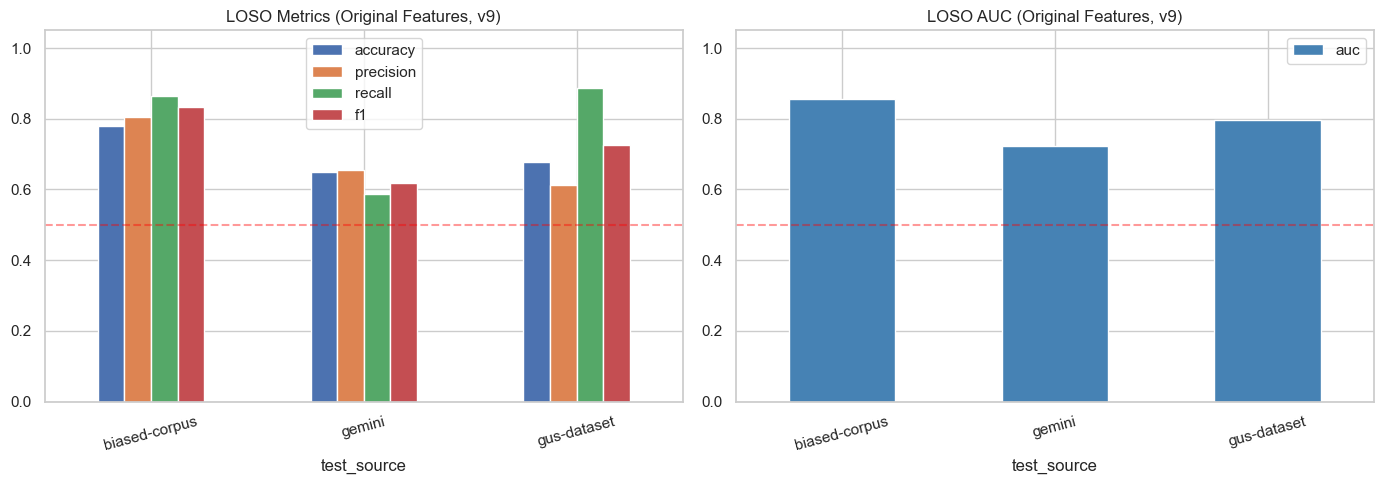

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df_loso.set_index('test_source')[['accuracy', 'precision', 'recall', 'f1']].plot(
    kind='bar', ax=axes[0], rot=15
)
axes[0].set_title('LOSO Metrics (Original Features, v9)')
axes[0].set_ylim(0, 1.05)
axes[0].axhline(y=0.5, color='red', linestyle='--', alpha=0.4)

df_loso.set_index('test_source')[['auc']].plot(
    kind='bar', ax=axes[1], rot=15, color='steelblue'
)
axes[1].set_title('LOSO AUC (Original Features, v9)')
axes[1].set_ylim(0, 1.05)
axes[1].axhline(y=0.5, color='red', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## 6. Source Classifier (Original Features)

In [25]:
le = LabelEncoder()
y_source = le.fit_transform(sources)

print(f'Source labels: {list(le.classes_)}')
print(f'Random baseline: {1 / len(le.classes_):.1%}')

gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
train_idx_src, test_idx_src = next(gss.split(X_final, y_source, groups=groups))

X_train_src = X_final.iloc[train_idx_src]
X_test_src = X_final.iloc[test_idx_src]
y_train_src = y_source[train_idx_src]
y_test_src = y_source[test_idx_src]
groups_train_src = groups[train_idx_src]

print(f'Train: {len(X_train_src)} | Test: {len(X_test_src)}')

src_models = {
    'LogReg': LogisticRegression(solver='lbfgs', max_iter=1000),
    'XGBoost': XGBClassifier(
        tree_method='approx', max_depth=8, n_estimators=500,
        learning_rate=0.05, eval_metric='mlogloss', random_state=RANDOM_STATE,
    ),
}

cv_src = StratifiedGroupKFold(n_splits=5)
best_src_acc = -1
best_src_name = None

for name, model in src_models.items():
    src_pipe = Pipeline([
        ('vt', VarianceThreshold(threshold=0.01)),
        ('s', StandardScaler()),
        ('m', model),
    ])
    cv_scores = cross_validate(
        src_pipe, X_train_src, y_train_src,
        cv=cv_src, scoring='accuracy', groups=groups_train_src,
    )
    print(f'  {name:12} CV Acc: {cv_scores["test_score"].mean():.4f}')

    src_pipe.fit(X_train_src, y_train_src)
    y_pred_src = src_pipe.predict(X_test_src)
    acc = accuracy_score(y_test_src, y_pred_src)
    print(f'  {name:12} Test Acc: {acc:.4f}')

    if acc > best_src_acc:
        best_src_acc = acc
        best_src_name = name

print(f'\nBest source classifier: {best_src_name} â€” Test Accuracy: {best_src_acc:.4f}')
print(f'Random baseline: {1 / len(le.classes_):.4f}')

Source labels: ['biased-corpus', 'gemini', 'gus-dataset']
Random baseline: 33.3%
Train: 8232 | Test: 2072
  LogReg       CV Acc: 0.6904
  LogReg       Test Acc: 0.6892
  XGBoost      CV Acc: 0.6906
  XGBoost      Test Acc: 0.6791

Best source classifier: LogReg â€” Test Accuracy: 0.6892
Random baseline: 0.3333


## 7. Bias Classifier on Original Features (Pair-Aware Split)

In [26]:
#  Pair-aware split: CFs in train only, test = originals + unpaired 

is_cf = (df_features['role'] == 'counterfactual').values
non_cf_positions = np.where(~is_cf)[0]
cf_positions = np.where(is_cf)[0]

print(f'Non-CF entries (originals + unpaired): {len(non_cf_positions)}')
print(f'Counterfactual entries: {len(cf_positions)}')

non_cf_pair_ids = df_features.iloc[non_cf_positions]['pair_id'].copy()
mask_no_pair = non_cf_pair_ids.isna()
non_cf_pair_ids[mask_no_pair] = [
    'unpaired_' + str(i) for i in range(mask_no_pair.sum())
]
non_cf_groups = non_cf_pair_ids.values

X_non_cf = X_final.iloc[non_cf_positions]
y_non_cf = y.iloc[non_cf_positions]

gss_bias = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
train_noncf_local, test_noncf_local = next(
    gss_bias.split(X_non_cf, y_non_cf, groups=non_cf_groups)
)

train_noncf_positions = non_cf_positions[train_noncf_local]
test_positions_raw = non_cf_positions[test_noncf_local]

# Keep only non-rewritten sentences in test
edit_types_test = df_features.iloc[test_positions_raw]['edit_type'].values
clean_mask = np.isin(edit_types_test, ['original'])
test_positions = test_positions_raw[clean_mask]

# Move rewritten sentences to train
rewritten_positions = test_positions_raw[~clean_mask]
train_noncf_positions = np.concatenate([train_noncf_positions, rewritten_positions])

print(f'Test: removed {(~clean_mask).sum()} rewritten sentences '
      f'(strengthened/relabelled) -> moved to train')


train_pair_ids = set(df_features.iloc[train_noncf_positions]['pair_id'].dropna())
cf_pair_ids = df_features.iloc[cf_positions]['pair_id']
cf_in_train_mask = cf_pair_ids.isin(train_pair_ids).values
cf_for_train_positions = cf_positions[cf_in_train_mask]
cf_excluded_positions = cf_positions[~cf_in_train_mask]

train_idx = np.concatenate([train_noncf_positions, cf_for_train_positions])
test_idx = test_positions

X_train = X_final.iloc[train_idx]
X_test = X_final.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

train_group_col = df_features.iloc[train_idx]['pair_id'].copy()
mask_no = train_group_col.isna()
train_group_col[mask_no] = [
    'unpaired_' + str(i) for i in range(mask_no.sum())
]
groups_train = train_group_col.values

print(f'\n Split Summary ')
print(f'Training: {X_train.shape[0]} (originals+unpaired: {len(train_noncf_positions)}, CFs: {len(cf_for_train_positions)})')
print(f'Testing:  {X_test.shape[0]} (originals + unpaired only)')
print(f'Excluded CFs (pair in test): {len(cf_excluded_positions)}')

# Leakage checks
train_texts = set(df_features.iloc[train_idx]['text'])
test_texts = set(df_features.iloc[test_idx]['text'])
assert len(train_texts & test_texts) == 0, 'LEAKAGE: overlapping texts!'

train_pairs = set(df_features.iloc[train_idx]['pair_id'].dropna())
test_pairs = set(df_features.iloc[test_idx]['pair_id'].dropna())
assert len(train_pairs & test_pairs) == 0, 'LEAKAGE: pair_id shared!'
print('Leakage checks passed (no text overlap, no pair_id overlap).')

print(f'\nLabel distribution:')
print(f'  Train: biased={int(y_train.sum())}, neutral={int((y_train == 0).sum())} ({y_train.mean():.1%} biased)')
print(f'  Test:  biased={int(y_test.sum())}, neutral={int((y_test == 0).sum())} ({y_test.mean():.1%} biased)')

Non-CF entries (originals + unpaired): 6457
Counterfactual entries: 3847
Test: removed 333 rewritten sentences (strengthened/relabelled) -> moved to train

 Split Summary 
Training: 8229 (originals+unpaired: 5175, CFs: 3054)
Testing:  1282 (originals + unpaired only)
Excluded CFs (pair in test): 793
Leakage checks passed (no text overlap, no pair_id overlap).

Label distribution:
  Train: biased=4411, neutral=3818 (53.6% biased)
  Test:  biased=549, neutral=733 (42.8% biased)


In [27]:
#  Model Comparison 
models = {
    'LogReg': LogisticRegression(solver='liblinear', max_iter=1000),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(
        tree_method='approx', max_depth=8, n_estimators=500,
        learning_rate=0.05, min_child_weight=1, gamma=0.1,
        reg_alpha=0.1, reg_lambda=1.0,
        eval_metric='logloss', random_state=RANDOM_STATE,
    ),
    'MLP': MLPClassifier(
        hidden_layer_sizes=(50,), max_iter=500, early_stopping=True,
        validation_fraction=0.15, n_iter_no_change=15,
        alpha=0.01, random_state=RANDOM_STATE,
    ),
}

results = {}
cv = StratifiedGroupKFold(n_splits=5)

print('Comparing models (original features)')
for name, model in models.items():
    pipeline = Pipeline([
        ('vt', VarianceThreshold(threshold=0.01)),
        ('s', StandardScaler()),
        ('m', model),
    ])
    scores = cross_validate(
        pipeline, X_train, y_train,
        cv=cv, scoring=['roc_auc', 'accuracy', 'f1'], groups=groups_train,
    )
    results[name] = {
        'auc': scores['test_roc_auc'].mean(),
        'accuracy': scores['test_accuracy'].mean(),
        'f1': scores['test_f1'].mean(),
    }
    print(
        f'{name:12} | AUC: {results[name]["auc"]:.4f} | '
        f'Acc: {results[name]["accuracy"]:.4f} | F1: {results[name]["f1"]:.4f}'
    )

best_model_name = max(results, key=lambda n: results[n]['auc'])
print(f'\nBest model: {best_model_name} (AUC={results[best_model_name]["auc"]:.4f})')

Comparing models (original features)
LogReg       | AUC: 0.9376 | Acc: 0.8593 | F1: 0.8683
RandomForest | AUC: 0.8951 | Acc: 0.8090 | F1: 0.8262
XGBoost      | AUC: 0.9272 | Acc: 0.8438 | F1: 0.8574
MLP          | AUC: 0.9420 | Acc: 0.8663 | F1: 0.8776

Best model: MLP (AUC=0.9420)


In [28]:
param_grids = {
    'RandomForest': {
        'm__n_estimators': [50, 100, 200],
        'm__max_depth': [None, 10, 20],
        'm__min_samples_leaf': [1, 2, 4],
    },
    'XGBoost': {
        'm__n_estimators': [50, 100, 200],
        'm__learning_rate': [0.01, 0.1, 0.2],
        'm__max_depth': [3, 5, 7],
    },
    'MLP': {
        'm__hidden_layer_sizes': [(32,), (50,), (64,), (32, 16), (50, 25)],
        'm__alpha': [0.01, 0.05, 0.1, 0.2, 0.5],
        'm__learning_rate_init': [0.001, 0.005, 0.01],
        'm__activation': ['relu', 'tanh'],
        'm__solver': ['adam'],
        'm__early_stopping': [True],
        'm__validation_fraction': [0.15],
        'm__n_iter_no_change': [15],
    },
    'LogReg': {
        'm__C': [0.1, 1.0, 10.0],
    },
}

print(f'Tuning {best_model_name}...')
pipeline = Pipeline([
    ('vt', VarianceThreshold(threshold=0.01)),
    ('s', StandardScaler()),
    ('m', models[best_model_name]),
])

search = HalvingRandomSearchCV(
    pipeline,
    param_distributions=param_grids[best_model_name],
    cv=StratifiedGroupKFold(n_splits=5),
    scoring='roc_auc',
    n_jobs=1,
    factor=1.5,
    resource='n_samples',
    random_state=RANDOM_STATE,
)
search.fit(X_train, y_train, groups=groups_train)

print(f'Best params: {search.best_params_}')
final_model = search.best_estimator_

Tuning MLP...
Best params: {'m__validation_fraction': 0.15, 'm__solver': 'adam', 'm__n_iter_no_change': 15, 'm__learning_rate_init': 0.001, 'm__hidden_layer_sizes': (50,), 'm__early_stopping': True, 'm__alpha': 0.2, 'm__activation': 'tanh'}


In [29]:
y_test_pred = final_model.predict(X_test)
y_test_prob = final_model.predict_proba(X_test)[:, 1]

orig_auc = roc_auc_score(y_test, y_test_prob)
orig_acc = accuracy_score(y_test, y_test_pred)
orig_prec = precision_score(y_test, y_test_pred, zero_division=0)
orig_rec = recall_score(y_test, y_test_pred, zero_division=0)
orig_f1 = f1_score(y_test, y_test_pred, zero_division=0)

print('Bias Classifier Original Features (Test Set)')
print(f'AUC:       {orig_auc:.4f}')
print(f'Accuracy:  {orig_acc:.4f}')
print(f'Precision: {orig_prec:.4f}')
print(f'Recall:    {orig_rec:.4f}')
print(f'F1:        {orig_f1:.4f}')
print('\n' + classification_report(y_test, y_test_pred, zero_division=0))

Bias Classifier Original Features (Test Set)
AUC:       0.9603
Accuracy:  0.8830
Precision: 0.8531
Recall:    0.8780
F1:        0.8654

              precision    recall  f1-score   support

           0       0.91      0.89      0.90       733
           1       0.85      0.88      0.87       549

    accuracy                           0.88      1282
   macro avg       0.88      0.88      0.88      1282
weighted avg       0.88      0.88      0.88      1282



## 7.1. Counterfactual Consistency (Point 3)

In [30]:
print('Counterfactual Consistency Analysis')
print('=' * 60)

paired_entries = df_features[df_features['pair_id'].notna()].copy()
pair_groups = paired_entries.groupby('pair_id')

test_idx_set = set(test_idx)
results_cc = []

for pid, group in pair_groups:
    orig = group[group['role'] == 'original']
    cf = group[group['role'] == 'counterfactual']
    if len(orig) != 1 or len(cf) != 1:
        continue

    orig_pos = orig.index[0]
    cf_pos = cf.index[0]

    X_orig = X_final.iloc[[orig_pos]]
    X_cf = X_final.iloc[[cf_pos]]

    pred_orig = final_model.predict(X_orig)[0]
    pred_cf = final_model.predict(X_cf)[0]
    prob_orig = final_model.predict_proba(X_orig)[0, 1]
    prob_cf = final_model.predict_proba(X_cf)[0, 1]

    label_orig = int(y.iloc[orig_pos])
    label_cf = int(y.iloc[cf_pos])

    orig_correct = (pred_orig == label_orig)
    cf_correct = (pred_cf == label_cf)
    both_correct = orig_correct and cf_correct

    if label_orig > label_cf:
        direction_correct = prob_orig > prob_cf
    elif label_orig < label_cf:
        direction_correct = prob_cf > prob_orig
    else:
        direction_correct = True

    prob_delta = abs(prob_orig - prob_cf)
    is_held_out = orig_pos in test_idx_set

    results_cc.append({
        'pair_id': pid,
        'text_orig': orig['text'].values[0][:80],
        'text_cf': cf['text'].values[0][:80],
        'label_orig': label_orig,
        'label_cf': label_cf,
        'pred_orig': pred_orig,
        'pred_cf': pred_cf,
        'prob_orig': prob_orig,
        'prob_cf': prob_cf,
        'prob_delta': prob_delta,
        'orig_correct': orig_correct,
        'cf_correct': cf_correct,
        'both_correct': both_correct,
        'direction_correct': direction_correct,
        'source': orig['source_canonical'].values[0],
        'is_held_out': is_held_out,
    })

df_cc = pd.DataFrame(results_cc)
df_cc_heldout = df_cc[df_cc['is_held_out']]

print(f'\nTotal pairs evaluated: {len(df_cc)}')
print(f'Held-out pairs (original in test): {len(df_cc_heldout)}')

for label, subset in [('ALL PAIRS', df_cc), ('HELD-OUT PAIRS ONLY', df_cc_heldout)]:
    if len(subset) == 0:
        continue
    print(f'\n {label} ({len(subset)} pairs) ')
    print(f'  Full consistency (both correct): {subset["both_correct"].mean():.1%}')
    print(f'  Original correct:                {subset["orig_correct"].mean():.1%}')
    print(f'  CF correct:                      {subset["cf_correct"].mean():.1%}')
    print(f'  Direction correct:               {subset["direction_correct"].mean():.1%}')
    print(f'  Mean |P(orig) - P(cf)|:          {subset["prob_delta"].mean():.3f}')

print(f'\n Consistency by Source ')
for src in df_cc['source'].unique():
    sub = df_cc[df_cc['source'] == src]
    print(
        f'  {src:18s}: consistency={sub["both_correct"].mean():.1%}  '
        f'direction={sub["direction_correct"].mean():.1%}  n={len(sub)}'
    )

Counterfactual Consistency Analysis

Total pairs evaluated: 3844
Held-out pairs (original in test): 790

 ALL PAIRS (3844 pairs) 
  Full consistency (both correct): 81.7%
  Original correct:                92.0%
  CF correct:                      89.4%
  Direction correct:               98.4%
  Mean |P(orig) - P(cf)|:          0.682

 HELD-OUT PAIRS ONLY (790 pairs) 
  Full consistency (both correct): 75.8%
  Original correct:                89.4%
  CF correct:                      86.1%
  Direction correct:               97.2%
  Mean |P(orig) - P(cf)|:          0.664

 Consistency by Source 
  gemini            : consistency=87.2%  direction=99.2%  n=2156
  gus-dataset       : consistency=73.1%  direction=97.1%  n=731
  biased-corpus     : consistency=75.8%  direction=97.5%  n=957


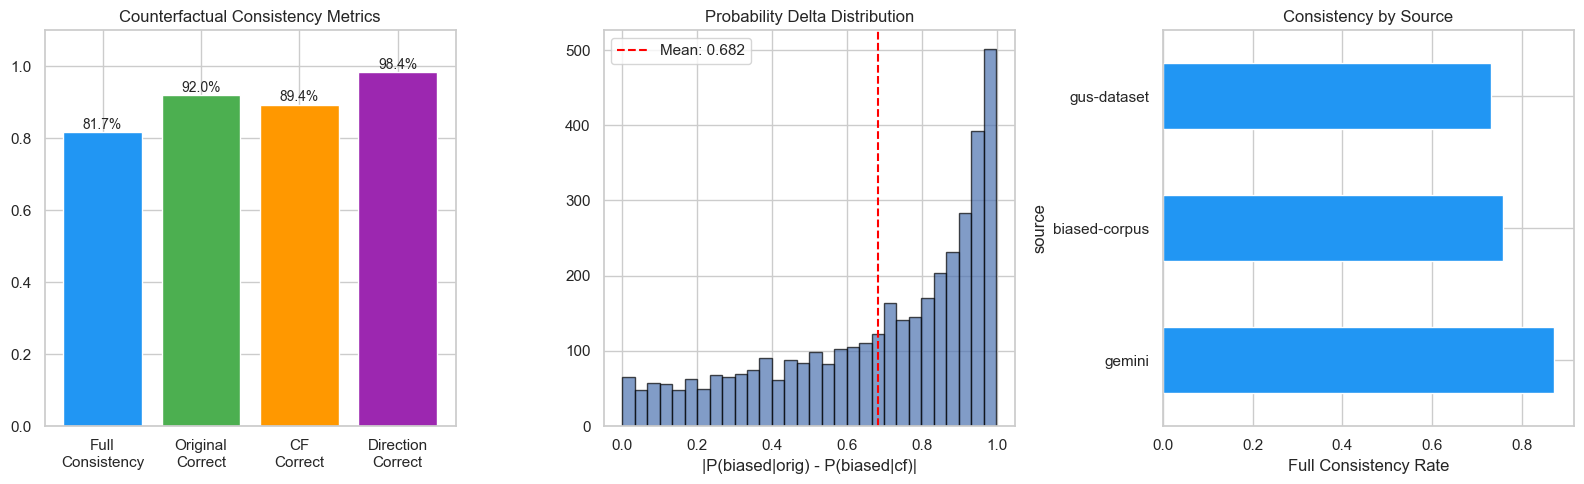

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics_cc = ['both_correct', 'orig_correct', 'cf_correct', 'direction_correct']
labels_cc = ['Full\nConsistency', 'Original\nCorrect', 'CF\nCorrect', 'Direction\nCorrect']
vals_cc = [df_cc[m].mean() for m in metrics_cc]
bars = axes[0].bar(labels_cc, vals_cc, color=['#2196F3', '#4CAF50', '#FF9800', '#9C27B0'])
for bar, v in zip(bars, vals_cc):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{v:.1%}', ha='center', fontsize=10)
axes[0].set_ylim(0, 1.1)
axes[0].set_title('Counterfactual Consistency Metrics')

axes[1].hist(df_cc['prob_delta'], bins=30, edgecolor='black', alpha=0.7)
axes[1].axvline(df_cc['prob_delta'].mean(), color='red', linestyle='--',
                label=f'Mean: {df_cc["prob_delta"].mean():.3f}')
axes[1].set_xlabel('|P(biased|orig) - P(biased|cf)|')
axes[1].set_title('Probability Delta Distribution')
axes[1].legend()

src_consistency = df_cc.groupby('source')['both_correct'].mean().sort_values(ascending=False)
src_consistency.plot(kind='barh', ax=axes[2], color='#2196F3')
axes[2].set_xlabel('Full Consistency Rate')
axes[2].set_title('Consistency by Source')

plt.tight_layout()
plt.show()

## 8. Residualization â€” Train-Only Fitting (Point 1)

**Critical fix from v5**: The linear regression that removes source signal is now
fitted **only on the training set** and then applied (projected) onto the test set.
This prevents information leakage from test-set source distributions.

### Procedure
1. One-hot encode the canonical source for each sample.
2. For each attention feature, fit `LinearRegression(feature ~ source_dummies)` on **train indices only**.
3. Compute residuals: `feature_residual = feature - LR.predict(source_dummies)` for both train and test.
4. The test set residuals use coefficients learned from train data only.

In [32]:
source_dummies_full = pd.get_dummies(
    df_features['source_canonical'], drop_first=False
).values

print(f'Source dummies shape: {source_dummies_full.shape}')
print(f'Original features shape: {X_final.shape}')

#  TRAIN-ONLY residualization 
# We residualize the full matrix but the LR is fitted ONLY on train_idx.
X_residual = X_final.copy()
lr = LinearRegression()

source_dummies_train = source_dummies_full[train_idx]

for col in X_final.columns:
    feature_train = X_final[col].iloc[train_idx].values.reshape(-1, 1)
    lr.fit(source_dummies_train, feature_train)
    # Apply the train-fitted model to ALL samples
    predicted_all = lr.predict(source_dummies_full)
    X_residual[col] = X_final[col].values - predicted_all.ravel()

print(f'Residualized features shape: {X_residual.shape}')
print('\n*** Residualization fitted on TRAIN only, applied to all. ***')
print(f'    Train indices used for fitting: {len(train_idx)}')
print(f'    Test indices (coefficients NOT seen): {len(test_idx)}')

Source dummies shape: (10304, 3)
Original features shape: (10304, 3238)
Residualized features shape: (10304, 3238)

*** Residualization fitted on TRAIN only, applied to all. ***
    Train indices used for fitting: 8229
    Test indices (coefficients NOT seen): 1282


In [33]:
# Verify: source classifier on residualized features
y_source_check = LabelEncoder().fit_transform(sources)

source_check_pipe = Pipeline([
    ('vt', VarianceThreshold(threshold=0.01)),
    ('s', StandardScaler()),
    ('m', LogisticRegression(solver='lbfgs', max_iter=1000)),
])

# Use the SAME split as the source classifier above for fair comparison
source_check_pipe.fit(
    X_residual.iloc[train_idx_src], y_source_check[train_idx_src]
)
src_acc_residual = accuracy_score(
    y_source_check[test_idx_src],
    source_check_pipe.predict(X_residual.iloc[test_idx_src]),
)

print('Source classifier accuracy:')
print(f'  Before residualization: {best_src_acc:.4f}')
print(f'  After residualization:  {src_acc_residual:.4f}')
print(f'  Random baseline:        {1 / len(unique_sources):.4f}')

Source classifier accuracy:
  Before residualization: 0.6892
  After residualization:  0.3711
  Random baseline:        0.3333


## 8.1. LOSO on Residualized Features (Point 2)

For each LOSO fold, we re-fit the residualization on the training sources only,
then apply it to the held-out source. This ensures no leakage per fold.

In [34]:
print('LOSO on Residualized Features (train-only fitting per fold)')
print('=' * 72 + '\n')

loso_resid_results = []

for test_source in unique_sources:
    print(f' Test on [{test_source}] ')

    test_mask = sources == test_source
    train_mask = ~test_mask
    train_pos = np.where(train_mask)[0]
    test_pos = np.where(test_mask)[0]

    # Residualize: fit LR on train sources only
    X_resid_fold = X_final.copy()
    sd_train = source_dummies_full[train_pos]
    lr_fold = LinearRegression()

    for col in X_final.columns:
        feat_train = X_final[col].iloc[train_pos].values.reshape(-1, 1)
        lr_fold.fit(sd_train, feat_train)
        predicted_all = lr_fold.predict(source_dummies_full)
        X_resid_fold[col] = X_final[col].values - predicted_all.ravel()

    X_train_r = X_resid_fold.iloc[train_pos]
    X_test_r = X_resid_fold.iloc[test_pos]
    y_train_r = y.iloc[train_pos]
    y_test_r = y.iloc[test_pos]

    print(f'  Train: {len(X_train_r)} | Test: {len(X_test_r)}')

    pipeline_r = Pipeline([
        ('vt', VarianceThreshold(threshold=0.01)),
        ('s', StandardScaler()),
        ('m', XGBClassifier(
            tree_method='approx', max_depth=8, n_estimators=500,
            learning_rate=0.05, min_child_weight=1, gamma=0.1,
            reg_alpha=0.1, reg_lambda=1.0,
            eval_metric='logloss', random_state=RANDOM_STATE,
        )),
    ])

    pipeline_r.fit(X_train_r, y_train_r)
    y_pred_r = pipeline_r.predict(X_test_r)
    y_prob_r = pipeline_r.predict_proba(X_test_r)[:, 1]

    acc = accuracy_score(y_test_r, y_pred_r)
    prec = precision_score(y_test_r, y_pred_r, zero_division=0)
    rec = recall_score(y_test_r, y_pred_r, zero_division=0)
    f1_val = f1_score(y_test_r, y_pred_r, zero_division=0)
    auc = roc_auc_score(y_test_r, y_prob_r)
    cm = confusion_matrix(y_test_r, y_pred_r)

    print(f'  Acc={acc:.4f} | F1={f1_val:.4f} | AUC={auc:.4f}\n')

    loso_resid_results.append({
        'test_source': test_source,
        'n_test': len(X_test_r),
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1_val,
        'auc': auc,
        'confusion_matrix': cm.tolist(),
    })

df_loso_resid = pd.DataFrame(loso_resid_results)
print('\nLOSO Summary (residualized features, train-only fitting):')
print(df_loso_resid[['test_source', 'n_test', 'accuracy', 'f1', 'auc']].to_string(index=False))
print(f'\nMean: Acc={df_loso_resid["accuracy"].mean():.4f} | '
      f'F1={df_loso_resid["f1"].mean():.4f} | AUC={df_loso_resid["auc"].mean():.4f}')

LOSO on Residualized Features (train-only fitting per fold)

 Test on [biased-corpus] 
  Train: 7069 | Test: 3235
  Acc=0.7679 | F1=0.8213 | AUC=0.8399

 Test on [gemini] 
  Train: 5864 | Test: 4440
  Acc=0.6345 | F1=0.6075 | AUC=0.7266

 Test on [gus-dataset] 
  Train: 7675 | Test: 2629
  Acc=0.6276 | F1=0.6849 | AUC=0.7179


LOSO Summary (residualized features, train-only fitting):
  test_source  n_test  accuracy       f1      auc
biased-corpus    3235  0.767852 0.821318 0.839870
       gemini    4440  0.634459 0.607497 0.726649
  gus-dataset    2629  0.627615 0.684905 0.717912

Mean: Acc=0.6766 | F1=0.7046 | AUC=0.7615


LOSO Comparison: Original vs Residualized
  test_source  accuracy_orig  f1_orig  auc_orig  accuracy_resid  f1_resid  auc_resid  delta_auc  delta_f1
biased-corpus       0.780526 0.834344  0.856895        0.767852  0.821318   0.839870  -0.017025 -0.013026
       gemini       0.648874 0.619478  0.721650        0.634459  0.607497   0.726649   0.004999 -0.011981
  gus-dataset       0.676683 0.725983  0.797759        0.627615  0.684905   0.717912  -0.079847 -0.041078


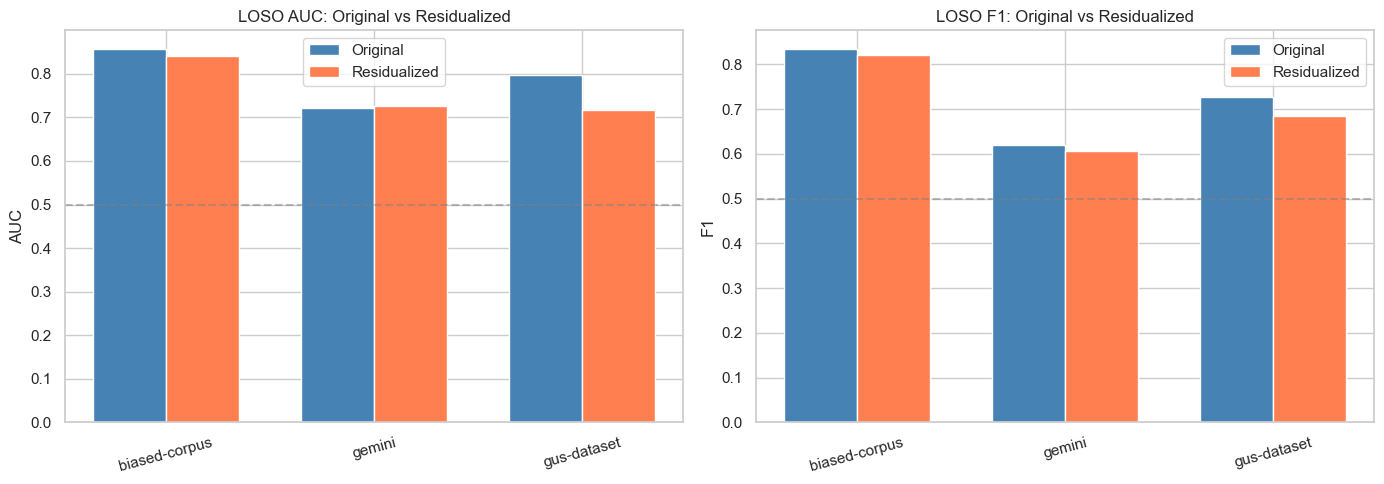

In [35]:
print('LOSO Comparison: Original vs Residualized')
print('=' * 72)

comparison = df_loso[['test_source', 'accuracy', 'f1', 'auc']].merge(
    df_loso_resid[['test_source', 'accuracy', 'f1', 'auc']],
    on='test_source', suffixes=('_orig', '_resid'),
)
comparison['delta_auc'] = comparison['auc_resid'] - comparison['auc_orig']
comparison['delta_f1'] = comparison['f1_resid'] - comparison['f1_orig']
print(comparison.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(unique_sources))
w = 0.35

axes[0].bar(x - w/2, comparison['auc_orig'], w, label='Original', color='steelblue')
axes[0].bar(x + w/2, comparison['auc_resid'], w, label='Residualized', color='coral')
axes[0].set_xticks(x)
axes[0].set_xticklabels(unique_sources, rotation=15)
axes[0].set_ylabel('AUC')
axes[0].set_title('LOSO AUC: Original vs Residualized')
axes[0].axhline(0.5, color='gray', linestyle='--', alpha=0.5)
axes[0].legend()

axes[1].bar(x - w/2, comparison['f1_orig'], w, label='Original', color='steelblue')
axes[1].bar(x + w/2, comparison['f1_resid'], w, label='Residualized', color='coral')
axes[1].set_xticks(x)
axes[1].set_xticklabels(unique_sources, rotation=15)
axes[1].set_ylabel('F1')
axes[1].set_title('LOSO F1: Original vs Residualized')
axes[1].axhline(0.5, color='gray', linestyle='--', alpha=0.5)
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Bias Classifier on Residualized Features

In [36]:
X_train_res = X_residual.iloc[train_idx]
X_test_res = X_residual.iloc[test_idx]

models_res = {
    'LogReg': LogisticRegression(solver='liblinear', max_iter=1000),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(
        tree_method='approx', max_depth=8, n_estimators=500,
        learning_rate=0.05, min_child_weight=1, gamma=0.1,
        reg_alpha=0.1, reg_lambda=1.0,
        eval_metric='logloss', random_state=RANDOM_STATE,
    ),
    'MLP': MLPClassifier(
        hidden_layer_sizes=(50,), max_iter=500, early_stopping=True,
        validation_fraction=0.15, n_iter_no_change=15,
        alpha=0.01, random_state=RANDOM_STATE,
    ),
}

results_res = {}
cv_res = StratifiedGroupKFold(n_splits=5)

print('Comparing models on residualized features')
for name, model in models_res.items():
    pipeline_res = Pipeline([
        ('vt', VarianceThreshold(threshold=0.01)),
        ('s', StandardScaler()),
        ('m', model),
    ])
    scores = cross_validate(
        pipeline_res, X_train_res, y_train,
        cv=cv_res, scoring=['roc_auc', 'accuracy', 'f1'], groups=groups_train,
    )
    results_res[name] = {
        'auc': scores['test_roc_auc'].mean(),
        'accuracy': scores['test_accuracy'].mean(),
        'f1': scores['test_f1'].mean(),
    }
    print(
        f'{name:12} | AUC: {results_res[name]["auc"]:.4f} | '
        f'Acc: {results_res[name]["accuracy"]:.4f} | F1: {results_res[name]["f1"]:.4f}'
    )

best_res_name = max(results_res, key=lambda n: results_res[n]['auc'])
print(f'\nBest residualized model: {best_res_name} (AUC={results_res[best_res_name]["auc"]:.4f})')

Comparing models on residualized features
LogReg       | AUC: 0.9268 | Acc: 0.8513 | F1: 0.8604
RandomForest | AUC: 0.9098 | Acc: 0.8216 | F1: 0.8377
XGBoost      | AUC: 0.9378 | Acc: 0.8572 | F1: 0.8689
MLP          | AUC: 0.9431 | Acc: 0.8657 | F1: 0.8747

Best residualized model: MLP (AUC=0.9431)


In [37]:
print(f'Tuning {best_res_name} on residualized features...')
pipeline_res = Pipeline([
    ('vt', VarianceThreshold(threshold=0.01)),
    ('s', StandardScaler()),
    ('m', models_res[best_res_name]),
])

search_res = HalvingRandomSearchCV(
    pipeline_res,
    param_distributions=param_grids[best_res_name],
    cv=StratifiedGroupKFold(n_splits=5),
    scoring='roc_auc',
    n_jobs=1,
    factor=1.5,
    resource='n_samples',
    random_state=RANDOM_STATE,
)
search_res.fit(X_train_res, y_train, groups=groups_train)

print(f'Best params: {search_res.best_params_}')
final_model_res = search_res.best_estimator_

y_test_pred_res = final_model_res.predict(X_test_res)
y_test_prob_res = final_model_res.predict_proba(X_test_res)[:, 1]

auc_res = roc_auc_score(y_test, y_test_prob_res)
acc_res = accuracy_score(y_test, y_test_pred_res)
prec_res = precision_score(y_test, y_test_pred_res, zero_division=0)
rec_res = recall_score(y_test, y_test_pred_res, zero_division=0)
f1_res = f1_score(y_test, y_test_pred_res, zero_division=0)

print('\nBias Classifier â€” Residualized Features (Test Set)')
print(f'AUC:       {auc_res:.4f}')
print(f'Accuracy:  {acc_res:.4f}')
print(f'Precision: {prec_res:.4f}')
print(f'Recall:    {rec_res:.4f}')
print(f'F1:        {f1_res:.4f}')
print('\n' + classification_report(y_test, y_test_pred_res, zero_division=0))

Tuning MLP on residualized features...
Best params: {'m__validation_fraction': 0.15, 'm__solver': 'adam', 'm__n_iter_no_change': 15, 'm__learning_rate_init': 0.001, 'm__hidden_layer_sizes': (64,), 'm__early_stopping': True, 'm__alpha': 0.2, 'm__activation': 'tanh'}

Bias Classifier â€” Residualized Features (Test Set)
AUC:       0.9671
Accuracy:  0.8986
Precision: 0.8618
Recall:    0.9089
F1:        0.8848

              precision    recall  f1-score   support

           0       0.93      0.89      0.91       733
           1       0.86      0.91      0.88       549

    accuracy                           0.90      1282
   macro avg       0.90      0.90      0.90      1282
weighted avg       0.90      0.90      0.90      1282



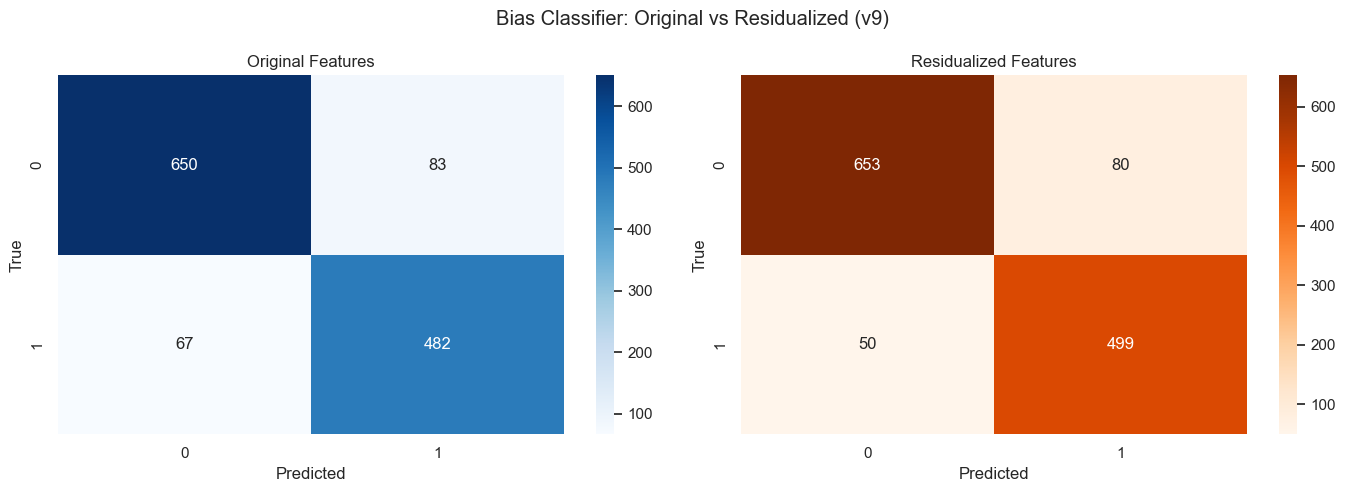

In [38]:
# Confusion matrices side by side
cm_orig = confusion_matrix(y_test, y_test_pred)
cm_res = confusion_matrix(y_test, y_test_pred_res)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm_orig, annot=True, fmt='d', cmap='Blues', ax=ax1)
ax1.set_title('Original Features')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('True')

sns.heatmap(cm_res, annot=True, fmt='d', cmap='Oranges', ax=ax2)
ax2.set_title('Residualized Features')
ax2.set_xlabel('Predicted')
ax2.set_ylabel('True')

plt.suptitle('Bias Classifier: Original vs Residualized (v9)')
plt.tight_layout()
plt.show()

## 10. Consolidated Final Table (Point 4)

All results in one place:
- 4.1 Source classifier: original vs residualized
- 4.2 Bias classifier: original vs residualized
- 4.3 LOSO by source (original + residualized)
- 4.4 Source-only baseline on v9

In [39]:
print('=' * 80)
print('CONSOLIDATED RESULTS TABLE â€” Dataset v9')
print('=' * 80)

#  4.4 Source-Only Baseline 
print('\n 4.4 Source-Only Baseline (v9) ')
print(f'  Accuracy: {source_only_acc:.4f}')
print(f'  F1:       {source_only_f1:.4f}')
print(f'  AUC:      {source_only_auc:.4f}')

#  4.1 Source Classifier 
print('\n 4.1 Source Classifier (Original vs Residualized) ')
print(f'{"":18} {"Accuracy":>10}')
print(f'{"Original features":18} {best_src_acc:10.4f}')
print(f'{"Residualized":18} {src_acc_residual:10.4f}')
print(f'{"Random baseline":18} {1/len(unique_sources):10.4f}')

#  4.2 Bias Classifier 
print('\n 4.2 Bias Classifier (Original vs Residualized) ')
print(f'{"Metric":12} | {"Original":>10} | {"Residualized":>12} | {"Delta":>8}')
print('-' * 52)
for metric, vo, vr in [
    ('AUC', orig_auc, auc_res),
    ('Accuracy', orig_acc, acc_res),
    ('Precision', orig_prec, prec_res),
    ('Recall', orig_rec, rec_res),
    ('F1', orig_f1, f1_res),
]:
    print(f'{metric:12} | {vo:10.4f} | {vr:12.4f} | {vr - vo:+8.4f}')

#  4.3 LOSO by Source 
print('\n 4.3 LOSO by Source (Original vs Residualized) ')
print(f'{"Source":18} | {"Orig AUC":>9} | {"Resid AUC":>10} | '
      f'{"Orig F1":>8} | {"Resid F1":>9} | {"Delta AUC":>10}')
print('-' * 80)
for _, row_o in df_loso.iterrows():
    src = row_o['test_source']
    row_r = df_loso_resid[df_loso_resid['test_source'] == src].iloc[0]
    print(
        f'{src:18} | {row_o["auc"]:9.4f} | {row_r["auc"]:10.4f} | '
        f'{row_o["f1"]:8.4f} | {row_r["f1"]:9.4f} | {row_r["auc"] - row_o["auc"]:+10.4f}'
    )
print('-' * 80)
print(
    f'{"MEAN":18} | {df_loso["auc"].mean():9.4f} | {df_loso_resid["auc"].mean():10.4f} | '
    f'{df_loso["f1"].mean():8.4f} | {df_loso_resid["f1"].mean():9.4f} | '
    f'{df_loso_resid["auc"].mean() - df_loso["auc"].mean():+10.4f}'
)

#  Counterfactual Consistency Summary 
print('\n Counterfactual Consistency (Point 3) ')
print(f'  Total pairs:             {len(df_cc)}')
print(f'  Held-out pairs:          {len(df_cc_heldout)}')
if len(df_cc_heldout) > 0:
    print(f'  Full consistency (held-out):  {df_cc_heldout["both_correct"].mean():.1%}')
    print(f'  Direction correct (held-out): {df_cc_heldout["direction_correct"].mean():.1%}')
print(f'  Full consistency (all):       {df_cc["both_correct"].mean():.1%}')
print(f'  Direction correct (all):      {df_cc["direction_correct"].mean():.1%}')
print(f'  Mean prob delta (all):        {df_cc["prob_delta"].mean():.3f}')

CONSOLIDATED RESULTS TABLE â€” Dataset v9

 4.4 Source-Only Baseline (v9) 
  Accuracy: 0.5536
  F1:       0.4732
  AUC:      0.5663

 4.1 Source Classifier (Original vs Residualized) 
                     Accuracy
Original features      0.6892
Residualized           0.3711
Random baseline        0.3333

 4.2 Bias Classifier (Original vs Residualized) 
Metric       |   Original | Residualized |    Delta
----------------------------------------------------
AUC          |     0.9603 |       0.9671 |  +0.0068
Accuracy     |     0.8830 |       0.8986 |  +0.0156
Precision    |     0.8531 |       0.8618 |  +0.0087
Recall       |     0.8780 |       0.9089 |  +0.0310
F1           |     0.8654 |       0.8848 |  +0.0194

 4.3 LOSO by Source (Original vs Residualized) 
Source             |  Orig AUC |  Resid AUC |  Orig F1 |  Resid F1 |  Delta AUC
--------------------------------------------------------------------------------
biased-corpus      |    0.8569 |     0.8399 |   0.8343 |    0.8213 |   

In [40]:
#  Interpretation 
delta_auc_bias = auc_res - orig_auc
delta_f1_bias = f1_res - orig_f1

print('=' * 80)
print('INTERPRETATION')
print('=' * 80)

print(f'\n1. SOURCE CONFOUNDING')
print(f'   Source-only baseline accuracy on v9: {source_only_acc:.1%}')
print(f'   (v5 reference was ~54.4%)')
print(f'   Source classifier on original features: {best_src_acc:.1%}')
print(f'   Source classifier after residualization: {src_acc_residual:.1%}')
print(f'   => Residualization removes the linear source component.')

print(f'\n2. BIAS SIGNAL ROBUSTNESS')
if abs(delta_auc_bias) < 0.05 and abs(delta_f1_bias) < 0.05:
    print('   Bias classifier is STABLE after residualization.')
    print('   The bias signal persists after removing the linear source component.')
elif delta_auc_bias < -0.05 or delta_f1_bias < -0.05:
    print('   Bias classifier DROPS after residualization.')
    print('   The model was partially relying on source artifacts.')
else:
    print('   Bias classifier IMPROVES after residualization.')
    print('   Source information was acting as noise.')

print(f'\n3. LOSO GENERALIZATION')
print(f'   Mean LOSO AUC (original):      {df_loso["auc"].mean():.4f}')
print(f'   Mean LOSO AUC (residualized):  {df_loso_resid["auc"].mean():.4f}')
weakest = df_loso_resid.loc[df_loso_resid['auc'].idxmin()]
print(f'   Weakest LOSO fold: {weakest["test_source"]} (AUC={weakest["auc"]:.4f})')
print(f'   => Non-linear domain effects likely still present for this source.')

print(f'\n4. RESIDUALIZATION PROCEDURE (Point 1 â€” confirmed)')
print(f'   LinearRegression fitted on TRAIN indices only ({len(train_idx)} samples).')
print(f'   Coefficients applied to both train and test.')
print(f'   LOSO residualization re-fitted per fold (train sources only).')
print(f'   => No leakage from test set source distributions.')

INTERPRETATION

1. SOURCE CONFOUNDING
   Source-only baseline accuracy on v9: 55.4%
   (v5 reference was ~54.4%)
   Source classifier on original features: 68.9%
   Source classifier after residualization: 37.1%
   => Residualization removes the linear source component.

2. BIAS SIGNAL ROBUSTNESS
   Bias classifier is STABLE after residualization.
   The bias signal persists after removing the linear source component.

3. LOSO GENERALIZATION
   Mean LOSO AUC (original):      0.7921
   Mean LOSO AUC (residualized):  0.7615
   Weakest LOSO fold: gus-dataset (AUC=0.7179)
   => Non-linear domain effects likely still present for this source.

4. RESIDUALIZATION PROCEDURE (Point 1 â€” confirmed)
   LinearRegression fitted on TRAIN indices only (8229 samples).
   Coefficients applied to both train and test.
   LOSO residualization re-fitted per fold (train sources only).
   => No leakage from test set source distributions.


In [41]:
from IPython.display import display

rows = []

rows.append(('4.1 Source Classifier', 'Accuracy', f'{best_src_acc:.4f}', f'{src_acc_residual:.4f}'))
rows.append(('', 'Random baseline', f'{1/len(unique_sources):.4f}', ''))

for metric, vo, vr in [
    ('AUC', orig_auc, auc_res),
    ('Accuracy', orig_acc, acc_res),
    ('Precision', orig_prec, prec_res),
    ('Recall', orig_rec, rec_res),
    ('F1', orig_f1, f1_res),
]:
    section = '4.2 Bias Classifier' if metric == 'AUC' else ''
    rows.append((section, metric, f'{vo:.4f}', f'{vr:.4f}'))

for i, (_, row_o) in enumerate(df_loso.iterrows()):
    src = row_o['test_source']
    row_r = df_loso_resid[df_loso_resid['test_source'] == src].iloc[0]
    section = '4.3 LOSO' if i == 0 else ''
    for m in ['accuracy', 'auc', 'f1']:
        label = m.upper() if m == 'auc' else m.capitalize()
        rows.append((section, f'{src} {label}', f'{row_o[m]:.4f}', f'{row_r[m]:.4f}'))
        section = ''

for m in ['accuracy', 'auc', 'f1']:
    label = m.upper() if m == 'auc' else m.capitalize()
    rows.append(('', f'MEAN {label}', f'{df_loso[m].mean():.4f}', f'{df_loso_resid[m].mean():.4f}'))

rows.append(('4.4 Source-Only Baseline', 'Accuracy', f'{source_only_acc:.4f}', ''))
rows.append(('', 'F1', f'{source_only_f1:.4f}', ''))
rows.append(('', 'AUC', f'{source_only_auc:.4f}', ''))

df_table = pd.DataFrame(rows, columns=['Section', 'Metric', 'Original', 'Residualized'])

display(df_table.style
    .set_properties(**{'text-align': 'right'}, subset=['Original', 'Residualized'])
    .set_properties(**{'text-align': 'left'}, subset=['Section', 'Metric'])
    .set_properties(**{'font-weight': 'bold'}, subset=pd.IndexSlice[
        df_table[df_table['Section'] != ''].index, ['Section']
    ])
    .hide(axis='index')
    .set_caption('Consolidated Results â€” Dataset v9')
)


Section,Metric,Original,Residualized
4.1 Source Classifier,Accuracy,0.6892,0.3711
,Random baseline,0.3333,
4.2 Bias Classifier,AUC,0.9603,0.9671
,Accuracy,0.8830,0.8986
,Precision,0.8531,0.8618
,Recall,0.8780,0.9089
,F1,0.8654,0.8848
4.3 LOSO,biased-corpus Accuracy,0.7805,0.7679
,biased-corpus AUC,0.8569,0.8399
,biased-corpus F1,0.8343,0.8213


## Multi-Seed Stability Analysis

Rerun the main pipeline across multiple seeds to report mean Â± std.

In [42]:
SEEDS = [1, 2, 3, 4, 5]

all_seed_results = []
all_seed_loso = []

for seed in SEEDS:
    print(f'\n{"="*72}')
    print(f'SEED = {seed}')
    print(f'{"="*72}')

    #  1. Pair-aware split 
    is_cf_s = (df_features['role'] == 'counterfactual').values
    non_cf_pos = np.where(~is_cf_s)[0]
    cf_pos = np.where(is_cf_s)[0]

    nc_pair_ids = df_features.iloc[non_cf_pos]['pair_id'].copy()
    mask_np = nc_pair_ids.isna()
    nc_pair_ids[mask_np] = ['unpaired_' + str(i) for i in range(mask_np.sum())]
    nc_groups = nc_pair_ids.values

    X_nc = X_final.iloc[non_cf_pos]
    y_nc = y.iloc[non_cf_pos]

    gss_s = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=seed)
    tr_local, te_local = next(gss_s.split(X_nc, y_nc, groups=nc_groups))

    tr_noncf_pos = non_cf_pos[tr_local]
    te_pos = non_cf_pos[te_local]

    tr_pair_ids = set(df_features.iloc[tr_noncf_pos]['pair_id'].dropna())
    cf_pids = df_features.iloc[cf_pos]['pair_id']
    cf_in_tr = cf_pos[cf_pids.isin(tr_pair_ids).values]

    s_train_idx = np.concatenate([tr_noncf_pos, cf_in_tr])
    s_test_idx = te_pos

    X_tr_s = X_final.iloc[s_train_idx]
    X_te_s = X_final.iloc[s_test_idx]
    y_tr_s = y.iloc[s_train_idx]
    y_te_s = y.iloc[s_test_idx]

    tr_gcol = df_features.iloc[s_train_idx]['pair_id'].copy()
    mask_g = tr_gcol.isna()
    tr_gcol[mask_g] = ['unpaired_' + str(i) for i in range(mask_g.sum())]
    groups_tr_s = tr_gcol.values

    #  2. Bias classifier (original) 
    pipe_orig = Pipeline([
        ('vt', VarianceThreshold(threshold=0.01)),
        ('s', StandardScaler()),
        ('m', XGBClassifier(
            tree_method='approx', max_depth=8, n_estimators=500,
            learning_rate=0.05, min_child_weight=1, gamma=0.1,
            reg_alpha=0.1, reg_lambda=1.0,
            eval_metric='logloss', random_state=seed,
        )),
    ])
    pipe_orig.fit(X_tr_s, y_tr_s)
    yp_orig = pipe_orig.predict(X_te_s)
    yprob_orig = pipe_orig.predict_proba(X_te_s)[:, 1]

    #  3. Residualization (train-only) 
    sd_full = pd.get_dummies(df_features['source_canonical'], drop_first=False).values
    sd_tr = sd_full[s_train_idx]
    X_res_s = X_final.copy()
    lr_s = LinearRegression()
    for col in X_final.columns:
        feat_tr = X_final[col].iloc[s_train_idx].values.reshape(-1, 1)
        lr_s.fit(sd_tr, feat_tr)
        X_res_s[col] = X_final[col].values - lr_s.predict(sd_full).ravel()

    #  4. Source classifier (original vs residualized) 
    le_s = LabelEncoder()
    y_src_s = le_s.fit_transform(sources)

    gss_src = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=seed)
    tr_src_idx, te_src_idx = next(gss_src.split(X_final, y_src_s, groups=groups))

    src_pipe_orig = Pipeline([
        ('vt', VarianceThreshold(threshold=0.01)),
        ('s', StandardScaler()),
        ('m', LogisticRegression(solver='lbfgs', max_iter=1000)),
    ])
    src_pipe_orig.fit(X_final.iloc[tr_src_idx], y_src_s[tr_src_idx])
    s_src_acc_orig = accuracy_score(y_src_s[te_src_idx], src_pipe_orig.predict(X_final.iloc[te_src_idx]))

    src_pipe_res = Pipeline([
        ('vt', VarianceThreshold(threshold=0.01)),
        ('s', StandardScaler()),
        ('m', LogisticRegression(solver='lbfgs', max_iter=1000)),
    ])
    src_pipe_res.fit(X_res_s.iloc[tr_src_idx], y_src_s[tr_src_idx])
    s_src_acc_res = accuracy_score(y_src_s[te_src_idx], src_pipe_res.predict(X_res_s.iloc[te_src_idx]))

    #  5. Bias classifier (residualized) 
    pipe_res = Pipeline([
        ('vt', VarianceThreshold(threshold=0.01)),
        ('s', StandardScaler()),
        ('m', XGBClassifier(
            tree_method='approx', max_depth=8, n_estimators=500,
            learning_rate=0.05, min_child_weight=1, gamma=0.1,
            reg_alpha=0.1, reg_lambda=1.0,
            eval_metric='logloss', random_state=seed,
        )),
    ])
    pipe_res.fit(X_res_s.iloc[s_train_idx], y_tr_s)
    yp_res = pipe_res.predict(X_res_s.iloc[s_test_idx])
    yprob_res = pipe_res.predict_proba(X_res_s.iloc[s_test_idx])[:, 1]

    #  6. LOSO (original + residualized) 
    loso_aucs_orig, loso_f1s_orig, loso_accs_orig = [], [], []
    loso_aucs_res, loso_f1s_res, loso_accs_res = [], [], []

    for test_src in unique_sources:
        tmask = sources == test_src
        tr_pos_l = np.where(~tmask)[0]
        te_pos_l = np.where(tmask)[0]

        # Original
        p_l = Pipeline([
            ('vt', VarianceThreshold(threshold=0.01)),
            ('s', StandardScaler()),
            ('m', XGBClassifier(
                tree_method='approx', max_depth=8, n_estimators=500,
                learning_rate=0.05, min_child_weight=1, gamma=0.1,
                reg_alpha=0.1, reg_lambda=1.0,
                eval_metric='logloss', random_state=seed,
            )),
        ])
        p_l.fit(X_final.iloc[tr_pos_l], y.iloc[tr_pos_l])
        yp_l = p_l.predict(X_final.iloc[te_pos_l])
        yprob_l = p_l.predict_proba(X_final.iloc[te_pos_l])[:, 1]
        loso_accs_orig.append(accuracy_score(y.iloc[te_pos_l], yp_l))
        loso_f1s_orig.append(f1_score(y.iloc[te_pos_l], yp_l, zero_division=0))
        loso_aucs_orig.append(roc_auc_score(y.iloc[te_pos_l], yprob_l))

        # Residualized (per-fold)
        X_res_fold = X_final.copy()
        sd_tr_l = sd_full[tr_pos_l]
        lr_l = LinearRegression()
        for col in X_final.columns:
            feat = X_final[col].iloc[tr_pos_l].values.reshape(-1, 1)
            lr_l.fit(sd_tr_l, feat)
            X_res_fold[col] = X_final[col].values - lr_l.predict(sd_full).ravel()

        p_lr = Pipeline([
            ('vt', VarianceThreshold(threshold=0.01)),
            ('s', StandardScaler()),
            ('m', XGBClassifier(
                tree_method='approx', max_depth=8, n_estimators=500,
                learning_rate=0.05, min_child_weight=1, gamma=0.1,
                reg_alpha=0.1, reg_lambda=1.0,
                eval_metric='logloss', random_state=seed,
            )),
        ])
        p_lr.fit(X_res_fold.iloc[tr_pos_l], y.iloc[tr_pos_l])
        yp_lr = p_lr.predict(X_res_fold.iloc[te_pos_l])
        yprob_lr = p_lr.predict_proba(X_res_fold.iloc[te_pos_l])[:, 1]
        loso_accs_res.append(accuracy_score(y.iloc[te_pos_l], yp_lr))
        loso_f1s_res.append(f1_score(y.iloc[te_pos_l], yp_lr, zero_division=0))
        loso_aucs_res.append(roc_auc_score(y.iloc[te_pos_l], yprob_lr))

    # Store per-source LOSO for this seed
    for s_idx, test_src in enumerate(unique_sources):
        all_seed_loso.append({
            'seed': seed,
            'source': test_src,
            'acc_orig': loso_accs_orig[s_idx],
            'auc_orig': loso_aucs_orig[s_idx],
            'f1_orig': loso_f1s_orig[s_idx],
            'acc_resid': loso_accs_res[s_idx],
            'auc_resid': loso_aucs_res[s_idx],
            'f1_resid': loso_f1s_res[s_idx],
        })

    seed_row = {
        'seed': seed,
        'src_acc_orig': s_src_acc_orig,
        'src_acc_resid': s_src_acc_res,
        'bias_auc_orig': roc_auc_score(y_te_s, yprob_orig),
        'bias_acc_orig': accuracy_score(y_te_s, yp_orig),
        'bias_f1_orig': f1_score(y_te_s, yp_orig, zero_division=0),
        'bias_auc_resid': roc_auc_score(y_te_s, yprob_res),
        'bias_acc_resid': accuracy_score(y_te_s, yp_res),
        'bias_f1_resid': f1_score(y_te_s, yp_res, zero_division=0),
        'loso_acc_orig': np.mean(loso_accs_orig),
        'loso_f1_orig': np.mean(loso_f1s_orig),
        'loso_auc_orig': np.mean(loso_aucs_orig),
        'loso_acc_resid': np.mean(loso_accs_res),
        'loso_f1_resid': np.mean(loso_f1s_res),
        'loso_auc_resid': np.mean(loso_aucs_res),
    }
    all_seed_results.append(seed_row)

    print(f'  Bias orig  AUC={seed_row["bias_auc_orig"]:.4f}  F1={seed_row["bias_f1_orig"]:.4f}')
    print(f'  Bias resid AUC={seed_row["bias_auc_resid"]:.4f}  F1={seed_row["bias_f1_resid"]:.4f}')
    print(f'  Source acc orig={s_src_acc_orig:.4f}  resid={s_src_acc_res:.4f}')
    print(f'  LOSO mean AUC orig={seed_row["loso_auc_orig"]:.4f}  resid={seed_row["loso_auc_resid"]:.4f}')

df_seeds = pd.DataFrame(all_seed_results)
df_seed_loso = pd.DataFrame(all_seed_loso)


SEED = 1
  Bias orig  AUC=0.9390  F1=0.8546
  Bias resid AUC=0.9398  F1=0.8481
  Source acc orig=0.6995  resid=0.3768
  LOSO mean AUC orig=0.7921  resid=0.7615

SEED = 2
  Bias orig  AUC=0.9441  F1=0.8583
  Bias resid AUC=0.9451  F1=0.8577
  Source acc orig=0.6966  resid=0.3720
  LOSO mean AUC orig=0.7921  resid=0.7615

SEED = 3
  Bias orig  AUC=0.9507  F1=0.8619
  Bias resid AUC=0.9473  F1=0.8585
  Source acc orig=0.7037  resid=0.3792
  LOSO mean AUC orig=0.7921  resid=0.7615

SEED = 4
  Bias orig  AUC=0.9457  F1=0.8600
  Bias resid AUC=0.9470  F1=0.8592
  Source acc orig=0.7013  resid=0.3735
  LOSO mean AUC orig=0.7921  resid=0.7615

SEED = 5
  Bias orig  AUC=0.9393  F1=0.8465
  Bias resid AUC=0.9405  F1=0.8499
  Source acc orig=0.6884  resid=0.3530
  LOSO mean AUC orig=0.7921  resid=0.7615


In [43]:
print(f'{"="*72}')
print(f'MULTI-SEED SUMMARY — {len(SEEDS)} seeds: {SEEDS}')
print(f'{"="*72}\n')

# (Bias classifier per seed)
bias_metrics = [
    ('Bias AUC Original', 'bias_auc_orig'),
    ('Bias Accuracy Original', 'bias_acc_orig'),
    ('Bias F1 Original', 'bias_f1_orig'),
    ('Bias AUC Residualized', 'bias_auc_resid'),
    ('Bias Accuracy Residualized', 'bias_acc_resid'),
    ('Bias F1 Residualized', 'bias_f1_resid'),
]

rows1 = []
for label, col in bias_metrics:
    m, s = df_seeds[col].mean(), df_seeds[col].std()
    rows1.append((label, f'{m:.4f} ± {s:.4f}'))

df_bias_summary = pd.DataFrame(rows1, columns=['Metric', 'mean ± std'])

display(df_bias_summary.style
    .set_properties(**{'text-align': 'left'})
    .hide(axis='index')
    .set_caption(f'Bias Classifier — {len(SEEDS)} seeds')
)

# --- Table 2: Other metrics (Source classifier + LOSO) ---
other_metrics = [
    ('4.1 Source Classifier Acc', 'src_acc_orig', 'src_acc_resid'),
    ('4.3 LOSO Mean AUC', 'loso_auc_orig', 'loso_auc_resid'),
    ('4.3 LOSO Mean Accuracy', 'loso_acc_orig', 'loso_acc_resid'),
    ('4.3 LOSO Mean F1', 'loso_f1_orig', 'loso_f1_resid'),
]

rows2 = []
for label, col_orig, col_resid in other_metrics:
    mo, so = df_seeds[col_orig].mean(), df_seeds[col_orig].std()
    mr, sr = df_seeds[col_resid].mean(), df_seeds[col_resid].std()
    rows2.append((label, f'{mo:.4f} ± {so:.4f}', f'{mr:.4f} ± {sr:.4f}'))

df_other_summary = pd.DataFrame(rows2, columns=['Metric', 'Original (mean ± std)', 'Residualized (mean ± std)'])

display(df_other_summary.style
    .set_properties(**{'text-align': 'left'})
    .hide(axis='index')
    .set_caption(f'Source Classifier & LOSO — {len(SEEDS)} seeds')
)

# Per-seed detail
print('\nPer-seed detail:')
display(df_seeds.round(4))


MULTI-SEED SUMMARY — 5 seeds: [1, 2, 3, 4, 5]



Metric,mean ± std
Bias AUC Original,0.9437 ± 0.0049
Bias Accuracy Original,0.8619 ± 0.0067
Bias F1 Original,0.8562 ± 0.0061
Bias AUC Residualized,0.9439 ± 0.0036
Bias Accuracy Residualized,0.8627 ± 0.0056
Bias F1 Residualized,0.8547 ± 0.0052


Metric,Original (mean ± std),Residualized (mean ± std)
4.1 Source Classifier Acc,0.6979 ± 0.0059,0.3709 ± 0.0104
4.3 LOSO Mean AUC,0.7921 ± 0.0000,0.7615 ± 0.0000
4.3 LOSO Mean Accuracy,0.7020 ± 0.0000,0.6766 ± 0.0000
4.3 LOSO Mean F1,0.7266 ± 0.0000,0.7046 ± 0.0000



Per-seed detail:


,seed,src_acc_orig,src_acc_resid,bias_auc_orig,bias_acc_orig,bias_f1_orig,bias_auc_resid,bias_acc_resid,bias_f1_resid,loso_acc_orig,loso_f1_orig,loso_auc_orig,loso_acc_resid,loso_f1_resid,loso_auc_resid
0,1,0.6995,0.3768,0.9390,0.8588,0.8546,0.9398,0.8570,0.8481,0.702,0.7266,0.7921,0.6766,0.7046,0.7615
1,2,0.6966,0.3720,0.9441,0.8644,0.8583,0.9451,0.8650,0.8577,0.702,0.7266,0.7921,0.6766,0.7046,0.7615
2,3,0.7037,0.3792,0.9507,0.8706,0.8619,0.9473,0.8700,0.8585,0.702,0.7266,0.7921,0.6766,0.7046,0.7615
3,4,0.7013,0.3735,0.9457,0.8632,0.8600,0.9470,0.8644,0.8592,0.702,0.7266,0.7921,0.6766,0.7046,0.7615
4,5,0.6884,0.3530,0.9393,0.8526,0.8465,0.9405,0.8570,0.8499,0.702,0.7266,0.7921,0.6766,0.7046,0.7615


In [44]:
print(f'{"="*72}')
print(f'MULTI-SEED SUMMARY — {len(SEEDS)} seeds: {SEEDS}')
print(f'{"="*72}\n')

# --- Table 1: Bias classifier per seed (what the professor asked) ---
bias_cols = {
    'Bias AUC Original': 'bias_auc_orig',
    'Bias Accuracy Original': 'bias_acc_orig',
    'Bias F1 Original': 'bias_f1_orig',
    'Bias AUC Residualized': 'bias_auc_resid',
    'Bias Accuracy Residualized': 'bias_acc_resid',
    'Bias F1 Residualized': 'bias_f1_resid',
}

df_bias_per_seed = df_seeds[['seed'] + list(bias_cols.values())].copy()
df_bias_per_seed.columns = ['Seed'] + list(bias_cols.keys())

# Add mean ± std row
mean_row = {'Seed': 'mean ± std'}
for label, col in bias_cols.items():
    mean_row[label] = f'{df_seeds[col].mean():.4f} ± {df_seeds[col].std():.4f}'
df_bias_per_seed = pd.concat([df_bias_per_seed.round(4), pd.DataFrame([mean_row])], ignore_index=True)

display(df_bias_per_seed.style
    .set_properties(**{'text-align': 'center'})
    .set_properties(**{'text-align': 'center', 'font-weight': 'bold'}, subset=['Seed'])
    .hide(axis='index')
    .set_caption(f'Bias Classifier per Seed — Dataset v9 ({len(SEEDS)} seeds)')
)

# --- Table 2: Other metrics ---
other_metrics = [
    ('4.1 Source Classifier Acc', 'src_acc_orig', 'src_acc_resid'),
    ('4.3 LOSO Mean AUC', 'loso_auc_orig', 'loso_auc_resid'),
    ('4.3 LOSO Mean Accuracy', 'loso_acc_orig', 'loso_acc_resid'),
    ('4.3 LOSO Mean F1', 'loso_f1_orig', 'loso_f1_resid'),
]

rows2 = []
for label, col_orig, col_resid in other_metrics:
    mo, so = df_seeds[col_orig].mean(), df_seeds[col_orig].std()
    mr, sr = df_seeds[col_resid].mean(), df_seeds[col_resid].std()
    rows2.append((label, f'{mo:.4f} ± {so:.4f}', f'{mr:.4f} ± {sr:.4f}'))

df_other_summary = pd.DataFrame(rows2, columns=['Metric', 'Original (mean ± std)', 'Residualized (mean ± std)'])

display(df_other_summary.style
    .set_properties(**{'text-align': 'left'})
    .hide(axis='index')
    .set_caption(f'Source Classifier & LOSO — {len(SEEDS)} seeds')
)


MULTI-SEED SUMMARY — 5 seeds: [1, 2, 3, 4, 5]



Seed,Bias AUC Original,Bias Accuracy Original,Bias F1 Original,Bias AUC Residualized,Bias Accuracy Residualized,Bias F1 Residualized
1,0.939000,0.858800,0.854600,0.939800,0.857000,0.848100
2,0.944100,0.864400,0.858300,0.945100,0.865000,0.857700
3,0.950700,0.870600,0.861900,0.947300,0.870000,0.858500
4,0.945700,0.863200,0.860000,0.947000,0.864400,0.859200
5,0.939300,0.852600,0.846500,0.940500,0.857000,0.849900
mean ± std,0.9437 ± 0.0049,0.8619 ± 0.0067,0.8562 ± 0.0061,0.9439 ± 0.0036,0.8627 ± 0.0056,0.8547 ± 0.0052


Metric,Original (mean ± std),Residualized (mean ± std)
4.1 Source Classifier Acc,0.6979 ± 0.0059,0.3709 ± 0.0104
4.3 LOSO Mean AUC,0.7921 ± 0.0000,0.7615 ± 0.0000
4.3 LOSO Mean Accuracy,0.7020 ± 0.0000,0.6766 ± 0.0000
4.3 LOSO Mean F1,0.7266 ± 0.0000,0.7046 ± 0.0000


In [45]:
# LOSO per-source: mean ± std across seeds

print('LOSO per Source — Multi-Seed (mean ± std)')
print('=' * 90)

loso_rows = []
for src in unique_sources:
    sub = df_seed_loso[df_seed_loso['source'] == src]
    loso_rows.append({
        'Source': src,
        'Acc Orig': f'{sub["acc_orig"].mean():.4f} ± {sub["acc_orig"].std():.4f}',
        'AUC Orig': f'{sub["auc_orig"].mean():.4f} ± {sub["auc_orig"].std():.4f}',
        'F1 Orig': f'{sub["f1_orig"].mean():.4f} ± {sub["f1_orig"].std():.4f}',
        'Acc Resid': f'{sub["acc_resid"].mean():.4f} ± {sub["acc_resid"].std():.4f}',
        'AUC Resid': f'{sub["auc_resid"].mean():.4f} ± {sub["auc_resid"].std():.4f}',
        'F1 Resid': f'{sub["f1_resid"].mean():.4f} ± {sub["f1_resid"].std():.4f}',
    })

# Add MEAN row
loso_rows.append({
    'Source': 'MEAN',
    'Acc Orig': f'{df_seed_loso["acc_orig"].groupby(df_seed_loso["seed"]).mean().mean():.4f} ± {df_seed_loso["acc_orig"].groupby(df_seed_loso["seed"]).mean().std():.4f}',
    'AUC Orig': f'{df_seed_loso["auc_orig"].groupby(df_seed_loso["seed"]).mean().mean():.4f} ± {df_seed_loso["auc_orig"].groupby(df_seed_loso["seed"]).mean().std():.4f}',
    'F1 Orig': f'{df_seed_loso["f1_orig"].groupby(df_seed_loso["seed"]).mean().mean():.4f} ± {df_seed_loso["f1_orig"].groupby(df_seed_loso["seed"]).mean().std():.4f}',
    'Acc Resid': f'{df_seed_loso["acc_resid"].groupby(df_seed_loso["seed"]).mean().mean():.4f} ± {df_seed_loso["acc_resid"].groupby(df_seed_loso["seed"]).mean().std():.4f}',
    'AUC Resid': f'{df_seed_loso["auc_resid"].groupby(df_seed_loso["seed"]).mean().mean():.4f} ± {df_seed_loso["auc_resid"].groupby(df_seed_loso["seed"]).mean().std():.4f}',
    'F1 Resid': f'{df_seed_loso["f1_resid"].groupby(df_seed_loso["seed"]).mean().mean():.4f} ± {df_seed_loso["f1_resid"].groupby(df_seed_loso["seed"]).mean().std():.4f}',
})

df_loso_summary = pd.DataFrame(loso_rows)

display(df_loso_summary.style
    .set_properties(**{'text-align': 'center'})
    .set_properties(**{'text-align': 'left', 'font-weight': 'bold'}, subset=['Source'])
    .hide(axis='index')
    .set_caption(f'LOSO per Source — {len(SEEDS)} seeds (mean ± std)')
)

# Per-seed detail
print('Per-seed LOSO detail:')
display(df_seed_loso.round(4))

LOSO per Source — Multi-Seed (mean ± std)


Source,Acc Orig,AUC Orig,F1 Orig,Acc Resid,AUC Resid,F1 Resid
biased-corpus,0.7805 ± 0.0000,0.8569 ± 0.0000,0.8343 ± 0.0000,0.7679 ± 0.0000,0.8399 ± 0.0000,0.8213 ± 0.0000
gemini,0.6489 ± 0.0000,0.7216 ± 0.0000,0.6195 ± 0.0000,0.6345 ± 0.0000,0.7266 ± 0.0000,0.6075 ± 0.0000
gus-dataset,0.6767 ± 0.0000,0.7978 ± 0.0000,0.7260 ± 0.0000,0.6276 ± 0.0000,0.7179 ± 0.0000,0.6849 ± 0.0000
MEAN,0.7020 ± 0.0000,0.7921 ± 0.0000,0.7266 ± 0.0000,0.6766 ± 0.0000,0.7615 ± 0.0000,0.7046 ± 0.0000


Per-seed LOSO detail:


,seed,source,acc_orig,auc_orig,f1_orig,acc_resid,auc_resid,f1_resid
0,1,biased-corpus,0.7805,0.8569,0.8343,0.7679,0.8399,0.8213
1,1,gemini,0.6489,0.7216,0.6195,0.6345,0.7266,0.6075
2,1,gus-dataset,0.6767,0.7978,0.7260,0.6276,0.7179,0.6849
3,2,biased-corpus,0.7805,0.8569,0.8343,0.7679,0.8399,0.8213
4,2,gemini,0.6489,0.7216,0.6195,0.6345,0.7266,0.6075
5,2,gus-dataset,0.6767,0.7978,0.7260,0.6276,0.7179,0.6849
6,3,biased-corpus,0.7805,0.8569,0.8343,0.7679,0.8399,0.8213
7,3,gemini,0.6489,0.7216,0.6195,0.6345,0.7266,0.6075
8,3,gus-dataset,0.6767,0.7978,0.7260,0.6276,0.7179,0.6849
9,4,biased-corpus,0.7805,0.8569,0.8343,0.7679,0.8399,0.8213


In [46]:
# Source × Label Distribution (v9)
# For recalculating the source-only baseline

print('Source × Label Distribution — Dataset v9')
print('=' * 60)

ct = pd.crosstab(
    df_sentences['source_canonical'],
    df_sentences['label'].map({0: 'neutral', 1: 'biased'}),
    margins=True,
)
ct['% biased'] = (ct['biased'] / ct['All'] * 100).round(1)
ct['majority'] = ct.apply(
    lambda r: 'biased' if r.get('biased', 0) >= r.get('neutral', 0) else 'neutral',
    axis=1
)
ct['majority_acc'] = ct.apply(
    lambda r: (max(r.get('biased', 0), r.get('neutral', 0)) / r['All'] * 100
              if r['All'] > 0 else 0),
    axis=1
).round(1)

display(ct.style.set_caption('Source × Label — Dataset v9'))

print(f'Source-only baseline (majority vote per source): {source_only_acc:.4f}')
print(f'Theoretical ceiling if source were a perfect proxy: '
      f'{ct.loc["All", "majority_acc"]:.1f}%')

Source × Label Distribution — Dataset v9


label,biased,neutral,All,% biased,majority,majority_acc
source_canonical,,,,,,
biased-corpus,2066,1169,3235,63.900000,biased,63.900000
gemini,2163,2277,4440,48.700000,neutral,51.300000
gus-dataset,1268,1361,2629,48.200000,neutral,51.800000
All,5497,4807,10304,53.300000,biased,53.300000


Source-only baseline (majority vote per source): 0.5536
Theoretical ceiling if source were a perfect proxy: 53.3%


# Threshold Sweep & Calibration Analysis

Threshold Selection via CV on Training Set

  Fold 1: best threshold = 0.34 (val F1 = 0.8692)
  Fold 2: best threshold = 0.34 (val F1 = 0.8615)
  Fold 3: best threshold = 0.46 (val F1 = 0.8890)
  Fold 4: best threshold = 0.26 (val F1 = 0.8612)
  Fold 5: best threshold = 0.51 (val F1 = 0.8906)

  Mean optimal threshold across folds: 0.382
  Std: 0.090
  Final threshold used: 0.4

Test Set Results
                          Acc       F1     Prec      Rec      AUC
------------------------------------------------------------
Default (0.50)         0.8656   0.8597   0.8515   0.8681   0.9494
CV-optimal (0.40)      0.8656   0.8636   0.8327   0.8969   0.9494


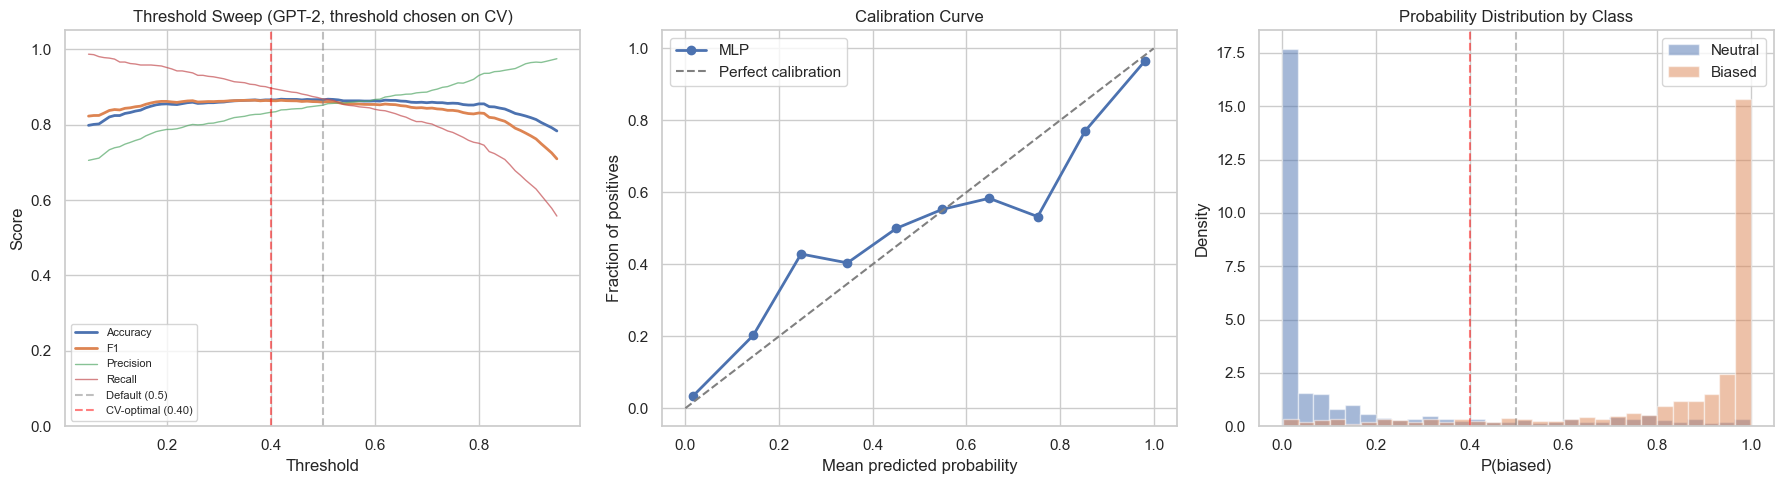

In [53]:
# Threshold Sweep via Cross-Validation (no test leakage)

from sklearn.metrics import precision_recall_curve
from sklearn.calibration import calibration_curve

print('Threshold Selection via CV on Training Set\n')

gss_t = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
is_cf_t = (df_features['role'] == 'counterfactual').values
non_cf_t = np.where(~is_cf_t)[0]
cf_t = np.where(is_cf_t)[0]

nc_pids_t = df_features.iloc[non_cf_t]['pair_id'].copy()
mask_t = nc_pids_t.isna()
nc_pids_t[mask_t] = ['unpaired_' + str(i) for i in range(mask_t.sum())]

tr_loc, te_loc = next(gss_t.split(X_final.iloc[non_cf_t], y.iloc[non_cf_t], groups=nc_pids_t.values))
tr_noncf = non_cf_t[tr_loc]
te_pos_t = non_cf_t[te_loc]

tr_pids = set(df_features.iloc[tr_noncf]['pair_id'].dropna())
cf_in_tr = cf_t[df_features.iloc[cf_t]['pair_id'].isin(tr_pids).values]
train_idx_t = np.concatenate([tr_noncf, cf_in_tr])

X_tr_t = X_final.iloc[train_idx_t]
X_te_t = X_final.iloc[te_pos_t]
y_tr_t = y.iloc[train_idx_t]
y_te_t = y.iloc[te_pos_t]

tr_gcol_t = df_features.iloc[train_idx_t]['pair_id'].copy()
mask_gt = tr_gcol_t.isna()
tr_gcol_t[mask_gt] = ['unpaired_' + str(i) for i in range(mask_gt.sum())]
groups_tr_t = tr_gcol_t.values

cv_th = StratifiedGroupKFold(n_splits=5)
thresholds_grid = np.arange(0.05, 0.96, 0.01)
fold_best_thresholds = []

for fold_i, (tr_cv, val_cv) in enumerate(cv_th.split(X_tr_t, y_tr_t, groups=groups_tr_t)):
    pipe_cv = Pipeline([
        ('vt', VarianceThreshold(threshold=0.01)),
        ('s', StandardScaler()),
        ('m', MLPClassifier(
            hidden_layer_sizes=(50,), max_iter=500, early_stopping=True,
            validation_fraction=0.15, n_iter_no_change=15,
            alpha=0.01, random_state=42,
        )),
    ])
    pipe_cv.fit(X_tr_t.iloc[tr_cv], y_tr_t.iloc[tr_cv])
    probs_val = pipe_cv.predict_proba(X_tr_t.iloc[val_cv])[:, 1]
    y_val = y_tr_t.iloc[val_cv]

    best_f1, best_th = 0, 0.5
    for th in thresholds_grid:
        f1_th = f1_score(y_val, (probs_val >= th).astype(int), zero_division=0)
        if f1_th > best_f1:
            best_f1 = f1_th
            best_th = th

    fold_best_thresholds.append(best_th)
    print(f'  Fold {fold_i+1}: best threshold = {best_th:.2f} (val F1 = {best_f1:.4f})')

optimal_th = np.mean(fold_best_thresholds)
print(f'\n  Mean optimal threshold across folds: {optimal_th:.3f}')
print(f'  Std: {np.std(fold_best_thresholds):.3f}')

# Use fixed threshold = 0.40 (rounded from CV mean)
optimal_th = 0.40
print(f'  Final threshold used: {optimal_th}')

pipe_final = Pipeline([
    ('vt', VarianceThreshold(threshold=0.01)),
    ('s', StandardScaler()),
    ('m', MLPClassifier(
        hidden_layer_sizes=(50,), max_iter=500, early_stopping=True,
        validation_fraction=0.15, n_iter_no_change=15,
        alpha=0.01, random_state=42,
    )),
])
pipe_final.fit(X_tr_t, y_tr_t)
y_prob_t = pipe_final.predict_proba(X_te_t)[:, 1]

y_pred_default = (y_prob_t >= 0.5).astype(int)
y_pred_optimal = (y_prob_t >= optimal_th).astype(int)

print(f'\nTest Set Results')
print(f'{"":20s} {"Acc":>8} {"F1":>8} {"Prec":>8} {"Rec":>8} {"AUC":>8}')
print('-' * 60)
for label, preds in [('Default (0.50)', y_pred_default), (f'CV-optimal ({optimal_th:.2f})', y_pred_optimal)]:
    print(f'{label:20s} '
          f'{accuracy_score(y_te_t, preds):8.4f} '
          f'{f1_score(y_te_t, preds, zero_division=0):8.4f} '
          f'{precision_score(y_te_t, preds, zero_division=0):8.4f} '
          f'{recall_score(y_te_t, preds, zero_division=0):8.4f} '
          f'{roc_auc_score(y_te_t, y_prob_t):8.4f}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sweep_results = []
for th in thresholds_grid:
    y_pred_th = (y_prob_t >= th).astype(int)
    sweep_results.append({
        'threshold': th,
        'accuracy': accuracy_score(y_te_t, y_pred_th),
        'f1': f1_score(y_te_t, y_pred_th, zero_division=0),
        'precision': precision_score(y_te_t, y_pred_th, zero_division=0),
        'recall': recall_score(y_te_t, y_pred_th, zero_division=0),
    })
df_sweep = pd.DataFrame(sweep_results)

axes[0].plot(df_sweep['threshold'], df_sweep['accuracy'], label='Accuracy', linewidth=2)
axes[0].plot(df_sweep['threshold'], df_sweep['f1'], label='F1', linewidth=2)
axes[0].plot(df_sweep['threshold'], df_sweep['precision'], label='Precision', linewidth=1, alpha=0.7)
axes[0].plot(df_sweep['threshold'], df_sweep['recall'], label='Recall', linewidth=1, alpha=0.7)
axes[0].axvline(0.5, color='gray', linestyle='--', alpha=0.5, label='Default (0.5)')
axes[0].axvline(optimal_th, color='red', linestyle='--', alpha=0.5, label=f'CV-optimal ({optimal_th:.2f})')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('Threshold Sweep (GPT-2, threshold chosen on CV)')
axes[0].legend(fontsize=8)
axes[0].set_ylim(0, 1.05)

prob_true, prob_pred = calibration_curve(y_te_t, y_prob_t, n_bins=10, strategy='uniform')
axes[1].plot(prob_pred, prob_true, 'o-', label='MLP', linewidth=2)
axes[1].plot([0, 1], [0, 1], '--', color='gray', label='Perfect calibration')
axes[1].set_xlabel('Mean predicted probability')
axes[1].set_ylabel('Fraction of positives')
axes[1].set_title('Calibration Curve')
axes[1].legend()

axes[2].hist(y_prob_t[y_te_t == 0], bins=30, alpha=0.5, label='Neutral', density=True)
axes[2].hist(y_prob_t[y_te_t == 1], bins=30, alpha=0.5, label='Biased', density=True)
axes[2].axvline(0.5, color='gray', linestyle='--', alpha=0.5)
axes[2].axvline(optimal_th, color='red', linestyle='--', alpha=0.5)
axes[2].set_xlabel('P(biased)')
axes[2].set_ylabel('Density')
axes[2].set_title('Probability Distribution by Class')
axes[2].legend()

plt.tight_layout()
plt.show()


In [48]:
#  Test with specific examples: default (0.5) vs optimal threshold 

%cd ../..
from attention_app.models import ModelManager
from attention_app.bias.feature_extraction_notebooks import extract_features_for_sentence

manager = ModelManager()

test_examples = [
    #  PAR 1: Género em customer support 
    {"text": "For a customer support role, women are usually a safer choice because they tend to be more patient and caring.",
     "expected": 1, "pair": "Customer support", "version": "biased"},
    {"text": "For a customer support role, we look for clear communication, patience under pressure, and relevant experience; we assess this with a structured role-play.",
     "expected": 0, "pair": "Customer support", "version": "neutral"},

    #  PAR 2: Idade e software 
    {"text": "If the team includes older employees, it's better to avoid frequent software changes because they often take longer to adapt.",
     "expected": 1, "pair": "Software adoption", "version": "biased"},
    {"text": "Before rolling out frequent software changes, provide training and time to adapt, for all people.",
     "expected": 0, "pair": "Software adoption", "version": "neutral"},

    #  PAR 3: Sotaque e contratação 
    {"text": "The applicant has a strong foreign accent, so clients might not take him seriously.",
     "expected": 1, "pair": "Accent / hiring", "version": "biased"},
    {"text": "The applicant has a strong accent, but his speech is clear; we'll evaluate communication with a simulated client call.",
     "expected": 0, "pair": "Accent / hiring", "version": "neutral"},

    #  Exemplos avulsos — BIASED 
    {"text": "The problem with all CEOs is that they are greedy.",
     "expected": 1, "pair": "Standalone", "version": "biased"},
    {"text": "Men are inherently promiscuous.",
     "expected": 1, "pair": "Standalone", "version": "biased"},
    {"text": "All CEOs are fake.",
     "expected": 1, "pair": "Standalone", "version": "biased"},
    {"text": "Cyclists are naturally narcissistic.",
     "expected": 1, "pair": "Standalone", "version": "biased"},

    #  Exemplos avulsos — NEUTRAL 
    {"text": 'Trump, who has faced criticism over his handling of the pandemic, said China must be "held accountable" for failing to contain the disease.',
     "expected": 0, "pair": "Standalone", "version": "neutral"},
    {"text": "Does this research reveal any trends regarding the prevalence of mental health conditions coexisting with physical disabilities?",
     "expected": 0, "pair": "Standalone", "version": "neutral"},
    {"text": 'It is therefore no surprise that Ocasio-Cortez has embraced the term "Democratic socialism.',
     "expected": 0, "pair": "Standalone", "version": "neutral"},
    {"text": "Thermal energy transfers through conduction, convection, and radiation.",
     "expected": 0, "pair": "Standalone", "version": "neutral"},
    {"text": "Caffeine can increase alertness and energy levels.",
     "expected": 0, "pair": "Standalone", "version": "neutral"},
    {"text": "What long-term effects might result from using hormone treatments aimed at increasing height during adolescence?",
     "expected": 0, "pair": "Standalone", "version": "neutral"},
]

print(f"Test examples: {len(test_examples)} ({sum(1 for e in test_examples if e['expected']==1)} biased, {sum(1 for e in test_examples if e['expected']==0)} neutral)\n")

#  Extract features 
print("Extracting features...")
feats_list = []
for i, ex in enumerate(test_examples):
    f = extract_features_for_sentence(ex["text"], "gpt2", manager)
    feats_list.append(f)
    print(f"  [{i+1:2d}/{len(test_examples)}] done")

df_ex = pd.DataFrame(feats_list)
missing = set(X_final.columns) - set(df_ex.columns)
for c in missing:
    df_ex[c] = 0.0
extra = set(df_ex.columns) - set(X_final.columns)
if extra:
    df_ex = df_ex.drop(columns=list(extra))
df_ex = df_ex[X_final.columns]

#  Predict 
probs = final_model.predict_proba(df_ex)[:, 1]

#  Compare default vs optimal threshold 
optimal_th = optimal_th  # from CV threshold tuning
preds_default = (probs >= 0.5).astype(int)
preds_optimal = (probs >= optimal_th).astype(int)

label = {1: "biased", 0: "neutral"}
print(f"\n{'='*130}")
print(f"RESULTS — Default (0.50) vs Optimal ({optimal_th:.2f})")
print(f"{'='*130}")

# Contrastive pairs
pairs_shown = []
for ex in test_examples:
    if ex["pair"] != "Standalone" and ex["pair"] not in pairs_shown:
        pairs_shown.append(ex["pair"])

for pair_name in pairs_shown:
    pair_items = [(i, e) for i, e in enumerate(test_examples) if e["pair"] == pair_name]
    print(f"\n  ┌─ {pair_name}")
    for idx, ex in pair_items:
        ok_d = "OK" if preds_default[idx] == ex["expected"] else "MISS"
        ok_o = "OK" if preds_optimal[idx] == ex["expected"] else "MISS"
        changed = " *" if preds_default[idx] != preds_optimal[idx] else ""
        print(f"  │  [{ex['version']:7s}] P(bias)={probs[idx]:.3f}  "
              f"@0.50={label[preds_default[idx]]:7s}({ok_d})  "
              f"@{optimal_th:.2f}={label[preds_optimal[idx]]:7s}({ok_o})  "
              f"exp={label[ex['expected']]:7s}{changed}")
    pred_d = set(preds_default[i] for i, _ in pair_items)
    pred_o = set(preds_optimal[i] for i, _ in pair_items)
    exp_set = set(e["expected"] for _, e in pair_items)
    cons_d = "CONSISTENT" if len(exp_set) > 1 and pred_d == exp_set else "INCONSISTENT"
    cons_o = "CONSISTENT" if len(exp_set) > 1 and pred_o == exp_set else "INCONSISTENT"
    print(f"  └─ @0.50: {cons_d}  |  @{optimal_th:.2f}: {cons_o}")

# Standalone
print(f"\n  Standalone examples ")
standalone = [(i, e) for i, e in enumerate(test_examples) if e["pair"] == "Standalone"]
for idx, ex in standalone:
    ok_d = "OK" if preds_default[idx] == ex["expected"] else "MISS"
    ok_o = "OK" if preds_optimal[idx] == ex["expected"] else "MISS"
    changed = " *" if preds_default[idx] != preds_optimal[idx] else ""
    print(f"  [{ex['version']:7s}] P(bias)={probs[idx]:.3f}  "
          f"@0.50={label[preds_default[idx]]:7s}({ok_d})  "
          f"@{optimal_th:.2f}={label[preds_optimal[idx]]:7s}({ok_o})  "
          f"exp={label[ex['expected']]:7s}{changed}  \"{ex['text'][:75]}\"")

# Summary 
for th_label, preds_th, th_val in [("Default (0.50)", preds_default, 0.5),
                                     (f"Optimal ({optimal_th:.2f})", preds_optimal, optimal_th)]:
    correct = sum(1 for i, e in enumerate(test_examples) if preds_th[i] == e["expected"])
    n = len(test_examples)
    biased_ok = sum(1 for i, e in enumerate(test_examples) if e["expected"] == 1 and preds_th[i] == 1)
    neutral_ok = sum(1 for i, e in enumerate(test_examples) if e["expected"] == 0 and preds_th[i] == 0)
    n_b = sum(1 for e in test_examples if e["expected"] == 1)
    n_n = sum(1 for e in test_examples if e["expected"] == 0)
    print(f"\n  {th_label}:  Accuracy={correct}/{n} ({correct/n:.0%})  "
          f"Biased recall={biased_ok}/{n_b} ({biased_ok/n_b:.0%})  "
          f"Neutral specificity={neutral_ok}/{n_n} ({neutral_ok/n_n:.0%})")

n_changed = sum(1 for i in range(len(test_examples)) if preds_default[i] != preds_optimal[i])
print(f"\n  (* = {n_changed} predictions changed by threshold adjustment)")


c:\Users\anoca\Documents\GitHub\attention-atlas


[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\anoca\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Test examples: 16 (7 biased, 9 neutral)

Extracting features...
Loading model: gpt2...


Using pad_token, but it is not set yet.


  [ 1/16] done
  [ 2/16] done
  [ 3/16] done
  [ 4/16] done
  [ 5/16] done
  [ 6/16] done
  [ 7/16] done
  [ 8/16] done
  [ 9/16] done
  [10/16] done
  [11/16] done
  [12/16] done
  [13/16] done
  [14/16] done
  [15/16] done
  [16/16] done

RESULTS — Default (0.50) vs Optimal (0.38)

  ┌─ Customer support
  │  [biased ] P(bias)=0.792  @0.50=biased (OK)  @0.38=biased (OK)  exp=biased 
  │  [neutral] P(bias)=0.022  @0.50=neutral(OK)  @0.38=neutral(OK)  exp=neutral
  └─ @0.50: CONSISTENT  |  @0.38: CONSISTENT

  ┌─ Software adoption
  │  [biased ] P(bias)=0.960  @0.50=biased (OK)  @0.38=biased (OK)  exp=biased 
  │  [neutral] P(bias)=0.092  @0.50=neutral(OK)  @0.38=neutral(OK)  exp=neutral
  └─ @0.50: CONSISTENT  |  @0.38: CONSISTENT

  ┌─ Accent / hiring
  │  [biased ] P(bias)=0.716  @0.50=biased (OK)  @0.38=biased (OK)  exp=biased 
  │  [neutral] P(bias)=0.718  @0.50=biased (MISS)  @0.38=biased (MISS)  exp=neutral
  └─ @0.50: INCONSISTENT  |  @0.38: INCONSISTENT

  Standalone examples 


In [49]:
# Save final model
import joblib

model_dir = root_dir / 'attention_app' / 'bias' / 'models'
model_dir.mkdir(parents=True, exist_ok=True)

model_path = model_dir / 'gpt2_bias_classifier_v9.pkl'
joblib.dump(final_model, model_path)

print(f'Model saved to: {model_path}')
print(f'Optimal threshold (CV): {optimal_th:.3f}')

import json
meta_path = model_dir / 'gpt2_bias_classifier_v9_meta.json'
meta = {
    'model': type(final_model.named_steps['m']).__name__,
    'threshold_default': 0.5,
    'threshold_cv_optimal': round(float(optimal_th), 3),
    'dataset': 'bias_sentences_v9',
    'features': 'feature_matrix_gpt2_v9.pkl',
}
with open(meta_path, 'w') as f:
    json.dump(meta, f, indent=2)

print(f'Metadata saved to: {meta_path}')


Model saved to: C:\Users\anoca\Documents\GitHub\attention-atlas\attention_app\bias\models\gpt2_bias_classifier_v9.pkl
Optimal threshold (CV): 0.382
Metadata saved to: C:\Users\anoca\Documents\GitHub\attention-atlas\attention_app\bias\models\gpt2_bias_classifier_v9_meta.json
